## 요약
- 기존 전처리 코드에서는 정수 인코딩한 token들도 scaling을 진행함
- transformer에서 embedding model을 사용하려면 정수 값으로 입력 받아야 함
- 또한 중고 도서 데이터가 아닌 도서 정보만 사용
- 이에 맞게 코드 수정

In [1]:
import os, natsort, re
from tqdm import tqdm
import time, random

In [2]:
from itertools import repeat, chain

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_squared_log_error as msle

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats("png2x")
# 테마 설정: "default", "classic", "dark_background", "fivethirtyeight", "seaborn"
mpl.style.use("fivethirtyeight")
# 이미지가 레이아웃 안으로 들어오도록 함
mpl.rcParams.update({"figure.constrained_layout.use": True})
mpl.rcParams['axes.unicode_minus'] = False

In [3]:
from google.colab import drive

drive.mount('/content/drive/', force_remount=True)

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
#cd /content/drive/MyDrive/AI3_prjct2_aladin/

In [ ]:
cd /content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/

[Errno 2] No such file or directory: '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/research


In [3]:
# 로컬에서

plt.rc("font", family = "D2Coding")
plt.rcParams["axes.unicode_minus"] = False

In [4]:
PRJCT_PATH = '/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/'
#PRJCT_PATH = '/content/drive/MyDrive/WASSUP-ESTsoft-AI/project/project2/'
#PRJCT_PATH = '/content/drive/MyDrive/AI3_prjct2_aladin/aladin_usedbook/'
save_dir = 'processed/model_input'
dir_path = os.path.join(PRJCT_PATH,save_dir)
#dir_path = './'

In [5]:
dir_path

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/model_input'

In [6]:
import sys
sys.path.append(PRJCT_PATH)

In [7]:
RSLT_DIR = PRJCT_PATH + 'processed/'

bookinfo_name = 'bookinfo_ver{}_single.csv'.format(2.0)
bookinfo_path = os.path.join(RSLT_DIR,bookinfo_name)

sys.path.append(PRJCT_PATH)
from module_aladin.file_io import load_pkl, save_pkl
from module_aladin.data_process import pd_datetime_2_datenum

import itertools

In [8]:
def set_corpus_size(freq,size_feat,mode):
    # 입력받은 mode와 size_feat에 따라 size 크기 결정
    if mode == 'uniform':
        cond = freq['counts']>=freq['counts'].iloc[size_feat]
        size = np.sum(cond)
    elif mode =='ths':
        cond = freq[freq['counts'] > size_feat]
        size = np.sum(cond)
    else :
        if size_feat == None : size = len(freq)
#        elif size_feat > len(data) : size = len(freq)
        else : size = size_feat
    return size

def make_encoding_by_freq(freq,null_val='[PAD]',size_feat=None,mode=None):
    #빈도수 기반 정수 인코딩 dict 만들기
    # freq : token 별 등장 빈도 (value_count), size_feat : size관련 변수(max_size, ths등), mode : size 결정 방법
    df_freq = pd.DataFrame(freq).T
    df_freq = df_freq.rename(columns={0:'token',1:'counts'})
    temp = df_freq.sort_values(by='counts',ascending=False)
    size = set_corpus_size(temp,size_feat,mode)
    temp = temp.iloc[:size]
    temp['val'] = np.arange(size)+1
    temp2 = temp.set_index('token').to_dict()
    map_token_encode = temp2['val']
    map_token_encode[null_val]=0
    return map_token_encode

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0 
    return map_token[x] if x in map_token else oov_val

def make_author_encode_map(bookinfo,ths_author):
    pvtb = pd.pivot_table(data=bookinfo,index='Author',values='SalesPoint',aggfunc=np.sum)
    pvtb = pvtb.sort_values(by='SalesPoint',ascending=False)
    author_top_k= pvtb[pvtb['SalesPoint']>=ths_author].index
    encode_author = pd.DataFrame({'author' : author_top_k.values,'val':np.arange(1,len(author_top_k)+1)})
    encode_author = encode_author.set_index('author')
    return encode_author.to_dict()['val']

def make_publshr_encode_map(publshr_data,ths_publshr):
    stats = publshr_data.value_counts().sort_values(ascending=False)
    top_k_val = stats.iloc[ths_publshr]
    publshr_top_k = list(stats[stats >= top_k_val].index)
    return {
        publshr : n+1
        for n,publshr in enumerate(publshr_top_k)
    }
    

def make_store_encode_map(store_data):
    stores= store_data.value_counts().sort_values(ascending=False)
    return {
        place : n+1
        for n,place in enumerate(stores.index)
    }

In [152]:
#file_name = 'bookinfo_ver{}.csv'.format(1.0)
#file_path = os.path.join(RSLT_DIR,file_name)
bookinfo_raw = pd.read_csv(bookinfo_path)

In [153]:
cols = bookinfo_raw.columns.to_list()
x_idxs, y_idx = [0,2,3,4,5,6,9,10], 7
x_cols = [cols[i] for i in x_idxs]
y_col = cols[y_idx]

data_X, data_y  = bookinfo_raw[x_cols], bookinfo_raw[y_col]

In [154]:
from sklearn.model_selection import train_test_split

X_data, X_tst, y_data, y_tst = train_test_split(data_X,data_y,test_size=0.2,random_state=329)
X_trn, X_vld, y_trn, y_vld = train_test_split(X_data,y_data,test_size=0.2,random_state=329)

display(X_trn.columns)
display(X_trn.shape, y_trn.shape)
display(X_vld.shape, y_vld.shape)
display(X_tst.shape, y_tst.shape)

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category'],
      dtype='object')

(98835, 8)

(98835,)

(24709, 8)

(24709,)

(30887, 8)

(30887,)

In [155]:
data_dict = {
    'trn': {
        'X': X_trn,
        'y': y_trn
        },
    'vld':{
        'X': X_vld,
        'y': y_vld
        },
    'tst':{
        'X': X_tst,
        'y': y_tst
        
    }
}

In [156]:
display(data_dict['trn']['X'].info())
display(data_dict['vld']['X'].info())
display(data_dict['tst']['X'].info())

<class 'pandas.core.frame.DataFrame'>
Index: 98835 entries, 84226 to 37109
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       98834 non-null  object
 1   BName_sub   5416 non-null   object
 2   Author      98835 non-null  object
 3   Publshr     98835 non-null  object
 4   Author_mul  98835 non-null  bool  
 5   Pdate       98835 non-null  int64 
 6   SalesPoint  98835 non-null  int64 
 7   Category    98835 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 6.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 24709 entries, 134680 to 143289
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       24709 non-null  object
 1   BName_sub   1299 non-null   object
 2   Author      24709 non-null  object
 3   Publshr     24709 non-null  object
 4   Author_mul  24709 non-null  bool  
 5   Pdate       24709 non-null  int64 
 6   SalesPoint  24709 non-null  int64 
 7   Category    24709 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.5+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 30887 entries, 30824 to 33317
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BName       30887 non-null  object
 1   BName_sub   1573 non-null   object
 2   Author      30887 non-null  object
 3   Publshr     30887 non-null  object
 4   Author_mul  30887 non-null  bool  
 5   Pdate       30887 non-null  int64 
 6   SalesPoint  30887 non-null  int64 
 7   Category    30887 non-null  object
dtypes: bool(1), int64(2), object(5)
memory usage: 1.9+ MB


None

# EDA for filter outliers

In [157]:
bk_info = data_dict['trn']['X'].copy()
bk_info['Price'] = data_dict['trn']['y'].copy()
bk_info.columns

Index(['BName', 'BName_sub', 'Author', 'Publshr', 'Author_mul', 'Pdate',
       'SalesPoint', 'Category', 'Price'],
      dtype='object')

In [158]:
bk_info.Pdate = pd.to_datetime(bk_info.Pdate,format="%Y%m%d")

In [159]:
bk_info.Pdate = pd.to_datetime(bk_info.Pdate,format="%Y%m%d")
bk_info['year'] = bk_info.Pdate.dt.year
ths = 1995
cond = bk_info['year'] < ths 
print(np.mean(cond))
bk_info.loc[cond,'year'] = ths-1 

0.017402741943643447


In [160]:
fix_cate={
    '유아' : '아동/청소년',
    '청소년' : '아동/청소년',
    '청소년_추천도서' : '아동/청소년',
    '어린이' : '아동/청소년',
    '유아' : '아동/청소년',
    '일본 도서' : '외국어',
    '고전' : '인문학',
    '교육/자료' : '수험서/자격증'
}

filter_cate=['달력/기타']
df = bk_info.copy()
cond = df.Category.isin(fix_cate.keys())
df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
cond = df.Category.isin(filter_cate)
df= df[~cond]

In [161]:
cols = ['year','Category']

from itertools import product
from functools import reduce
from tqdm.auto import tqdm

def statify_df(df:pd.DataFrame,cols:list):
    col_val_lists = [np.unique(df[c]) for c in cols]
    col_vals_prod = list(product(*col_val_lists))
    rslt = dict()
    for idxs in tqdm(col_vals_prod):
        conds = [df[col] == val for col,val in zip(cols,idxs)]
        cond = reduce(lambda x,y : x & y, conds)
        rslt[idxs] = { 'data' : df[cond], 'slice' : cond}
    return rslt
        
sliced= statify_df(df,cols)

  0%|          | 0/620 [00:00<?, ?it/s]

In [162]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))

q = 0.03

for key,ele in sliced.items():
    data = ele['data']['Price']
    if len(data) == 0 : content = 0
    else : content = np.quantile(data,1-q).astype(int)
    rslt[key[0]][key[1]] = content

#fig, ax = plt.subplots(figsize=(20,8)) 
#sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

up_bnd = pd.DataFrame(rslt)

In [163]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))

q = 0.03

for key,ele in sliced.items():
    data = ele['data']['Price']
    if len(data) == 0 : content = 0
    else : content = np.quantile(data,q).astype(int)
    rslt[key[0]][key[1]] = content

#fig, ax = plt.subplots(figsize=(20,8)) 
#sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

lw_bnd = pd.DataFrame(rslt)

In [164]:
#bnd_diff = up_bnd-lw_bnd

ths_up = 50000 
ths_lw = 3000
#ths_diff = 10000

slice_dict = dict() 
ths_dict= dict() 

for key,ele in sliced.items():
    up, low = up_bnd.loc[key[1],key[0]],lw_bnd.loc[key[1],key[0]]
    #if up - low < ths_diff : 
    ths_dict[key]={
        'up' : max(up,ths_up),
        'lw' : max(low,ths_lw),
    }
    
for key,ele in sliced.items():
    data = ele['data']
    cond = (data['Price'] <= ths_dict[key]['up']) & (data['Price']>= ths_dict[key]['lw'])
    slice_dict[key] = data[cond]

In [165]:
len(pd.concat(list(slice_dict.values())))/len(df)

0.9678177453175174

In [166]:
answer_sheet = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict.items():
    answer_sheet[key[0]][key[1]] = np.median(ele['Price']) if len(ele)> 2 else np.nan
    
answer_sheet = pd.DataFrame(answer_sheet)
answer_sheet = answer_sheet.ffill(axis=1)
answer_sheet = answer_sheet.bfill(axis=1)

answer_sheet.to_dict()

cheat=dict()
for k1,ele in answer_sheet.to_dict().items():
    for k2,val in ele.items():
        cheat[f'{k1}|{k2}']=val

def cheat_sheet(X,sheet,cols):
    X = X.astype(str)
    X_keys = X[cols].apply(lambda x : '|'.join(x.values),axis=1)
    return X_keys.map(sheet)

In [167]:
X_vld = data_dict['vld']['X']
y_vld = data_dict['vld']['y']

def basic_filter(X,y):
    df = X.copy()
    cond = df.Category.isin(fix_cate.keys())
    df.loc[cond,'Category'] = df.loc[cond,'Category'].map(fix_cate)
    cond = df.Category.isin(filter_cate)
    X= df[~cond]
    y= y[~cond]
    
    X.Pdate = pd.to_datetime(X.Pdate,format="%Y%m%d")
    X['year'] = X.Pdate.dt.year
    ths = 1995
    cond = X['year'] < ths 
#    print(np.mean(cond))
    X.loc[cond,'year'] = ths-1 
    return X,y

X_vld,y_vld = basic_filter(data_dict['vld']['X'],data_dict['vld']['y'])
X_tst,y_tst = basic_filter(data_dict['tst']['X'],data_dict['tst']['y'])


/tmp/ipykernel_207050/3870411060.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.Pdate = pd.to_datetime(X.Pdate,format="%Y%m%d")
/tmp/ipykernel_207050/3870411060.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['year'] = X.Pdate.dt.year
/tmp/ipykernel_207050/3870411060.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

In [168]:
print('baseline')
rmse = lambda x,y: np.sqrt(mse(x,y))
y_prd = cheat_sheet(X_vld,cheat,cols)
print(r2_score(y_vld,y_prd),mape(y_vld,y_prd),rmse(y_vld,y_prd))
y_prd = cheat_sheet(X_tst,cheat,cols)
print(r2_score(y_tst,y_prd),mape(y_tst,y_prd),rmse(y_tst,y_prd))

baseline
0.32115967758177555 0.29720551217380636 6912.4534312880605
0.34972893915117464 0.2972276986133003 6449.458311607232


In [169]:
print('baseline')
X_vld,_,y_vld,_ = train_test_split(X_vld,y_vld,train_size=0.2,random_state=416)
X_tst,_,y_tst,_ = train_test_split(X_tst,y_tst,train_size=0.2,random_state=416)
rmse = lambda x,y: np.sqrt(mse(x,y))
y_prd = cheat_sheet(X_vld,cheat,cols)
print(r2_score(y_vld,y_prd),mape(y_vld,y_prd),rmse(y_vld,y_prd),len(X_vld))
y_prd = cheat_sheet(X_tst,cheat,cols)
print(r2_score(y_tst,y_prd),mape(y_tst,y_prd),rmse(y_tst,y_prd),len(X_tst))

baseline
0.3316620835685411 0.30566240352111934 6813.453376212959 4935
0.34461041375117696 0.3040625960251363 6571.674119228333 6170


## Sampling train data


<Axes: >

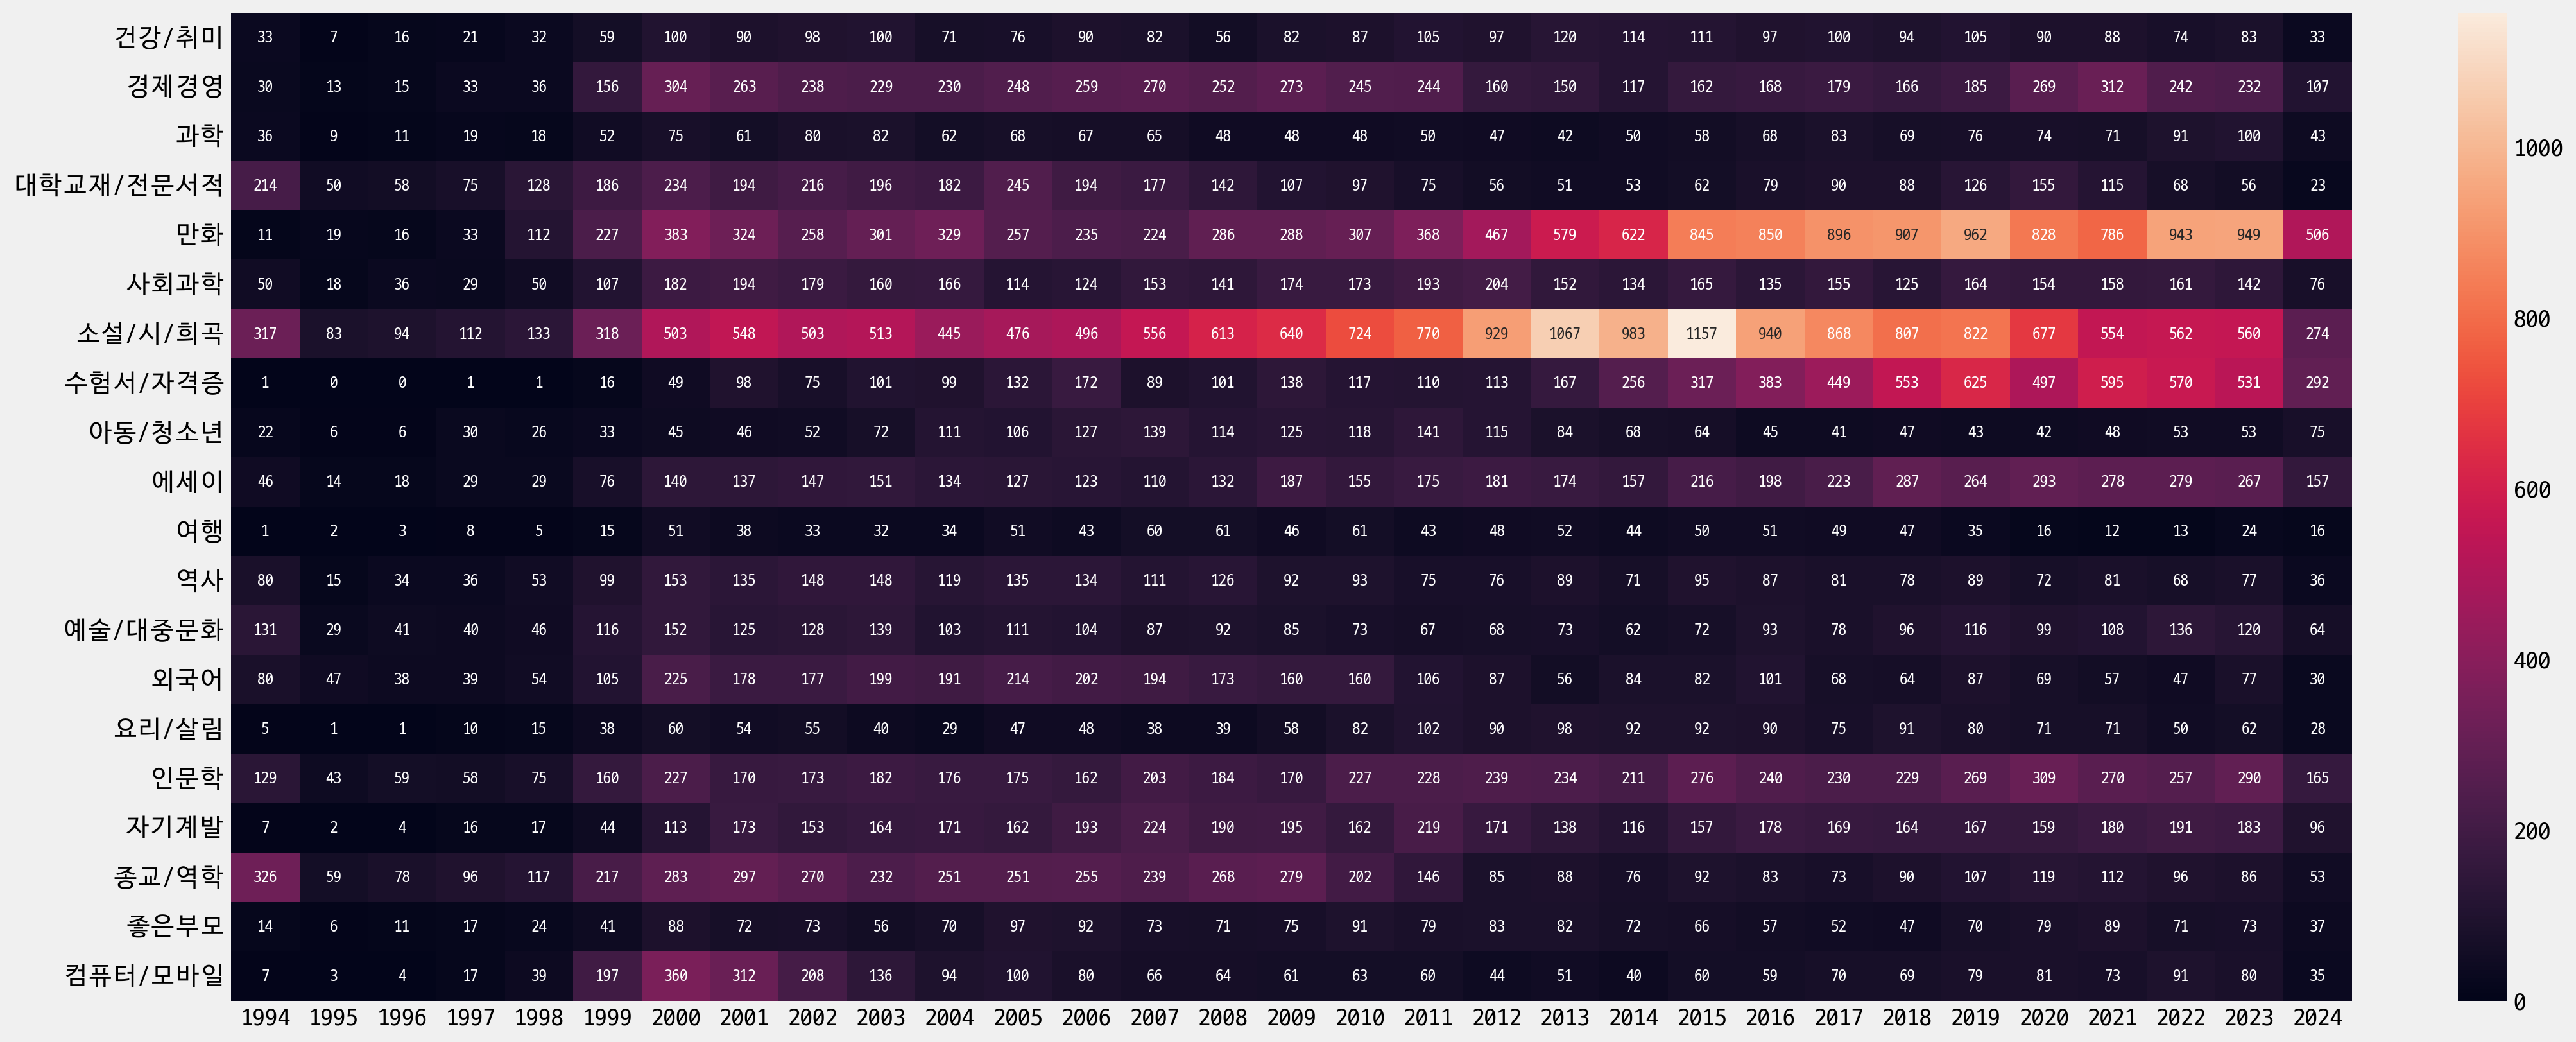

In [170]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict.items():
    rslt[key[0]][key[1]] = len(ele)
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

56.0 96.0 179.0
-128.5 363.5
0.02258064516129032 0.07580645161290323
0.2435483870967742 0.14677419354838708


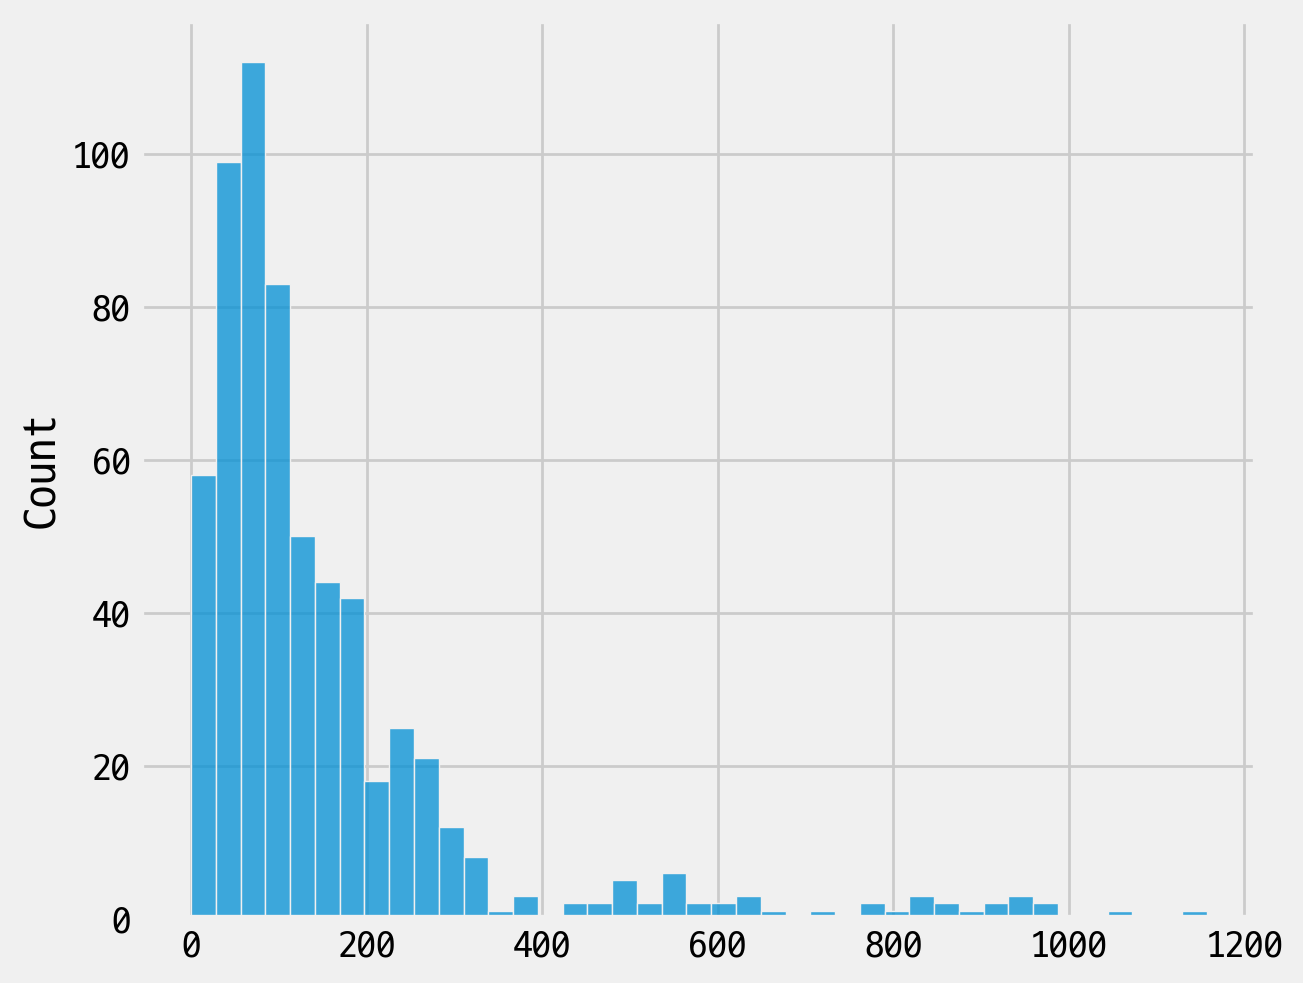

In [171]:
lens = pd.DataFrame(rslt).values.reshape(-1)
sns.histplot(lens)
q1 = np.quantile(lens,1/4)
q2 = np.quantile(lens,2/4)
q3 = np.quantile(lens,3/4)
print(q1,q2,q3)
iqr = q3-q1
print(q1-1.5*iqr,q3+1.5*iqr)
print(np.mean(lens<5),np.mean(lens>364))
print(np.mean(lens<55),np.mean(lens<40))

In [172]:
def remain_k_digits(n,k):
  r = np.floor(np.log10(n))
  temp = np.round(n/(10**r),k-1)
  temp = np.round(temp*(10**r),0)
  return (temp).astype(int)

def make_val_keys(data):
  lbnd = data.min()//1000
  ubnd = data.max()//1000
  temp = np.unique(remain_k_digits(np.arange(lbnd,ubnd+2),2)*1000)
  return temp[1:]

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0
    return map_token[x] if x in map_token else oov_val

def encode_to_2digit(data,keys):
  val = remain_k_digits(data,2)
  val[val < keys.min()] = keys.min()
  val[val > keys.max()] = keys.max()

  cond = val < 10000
  val[cond] = remain_k_digits(val[cond],1)
  encode_map= {
      k : i for i,k in enumerate(keys)
  }
  encode_1line = lambda y : list(map(lambda x : encode_tokens(encode_map,x),y))
  return np.apply_along_axis(encode_1line,0,val), encode_map

In [173]:
temp = pd.concat(slice_dict.values())

val_keys = make_val_keys(temp.Price)
_,encode_map = encode_to_2digit(temp.Price,val_keys)

In [174]:
def find_closest_idx(idxs,nums):
  numbers, iz = np.array(nums),np.array(idxs)
  subs = numbers[~np.isin(numbers,iz)]
  if len(subs) > 0:
    rslt = np.argsort(np.abs(subs.reshape(1,-1)-iz.reshape(-1,1)))
    return subs[rslt[:,0]]
  else :
    return np.ones(len(iz)) * np.median(numbers)

def make_ele_plural(data,key='strat'):
  while True:
    freq = np.unique(data[key],return_counts=True)
    cond = freq[1][:] == 1
    if np.sum(cond) == 0 : break
    targets =freq[0][cond]
    dest = find_closest_idx(targets,freq[0])
    idx_cond = data[key].isin(targets)
    trans = {t:d for t,d in zip(targets,dest)}
    data.loc[idx_cond,key] = data.loc[idx_cond,key].map(trans)
  return data

def make_class_sound(data,rate,key='strat'):  
  '''
  for split, there should be # of elements in sample > # of class of strat
  sice at least one element for each strat would be sampled
  '''
  n_train = int(len(data) * min(rate,1-rate))
  while True :
    classes = data[key].value_counts()
    if len(classes) <= n_train : break
    if len(classes) == 1 :break
    indices = classes.index
    trgt = indices[-1]
    cond = data[key]== trgt
    dest = find_closest_idx(trgt,indices) 
    data.loc[cond,key] = int(dest)
    
  rate_m = 1/len(data) if n_train==0 else rate
  return data,rate_m

def complete_part(part_coeff,infm,supm):
  if part_coeff is None  : return [[infm,supm]],[1]
  part_given = [x for x in part_coeff['part'] if x[1] > infm]
  part_given = [x for x in part_given if x[0] <= supm]
  if len(part_given) < 1 : return [[infm,supm]],[1]
  front = [infm]+[x[0] for x in part_given]+[min(part_given[-1][1],supm)]
  end = [max(infm,part_given[0][0])]+[x[1] for x in part_given]+[supm]
  rates = [1]+part_coeff['coeff']+[1]

  diff = np.array(end) - np.array(front)
  if np.sum(diff < 0) > 0 : raise Exception('part define error')
  diff = np.array(front[2:-1]) - np.array(end[1:-2])
  if np.sum(diff < 0) > 0 : raise Exception('part define error')
  
  parts,coeffz =list(),list()
  for i,(f,e,c) in enumerate(zip(front,end,rates)):
    if e - f != 0 : parts.append([f,e]), coeffz.append(c)
    if (i+1 < len(front)) and (e < front[i+1]) :
      parts.append([e,front[i+1]]), coeffz.append(1)
  
  return parts, coeffz  

def divide_parts(parts,y):
  return [ (bnd[0] <= y) & (y < bnd[1]) for bnd in parts]


In [175]:
def sample_data(data,rate,part_coeff=None):
  ''' 
  part_coeff: dict
  e.g.
  part : (a0,b0), ... ,(an,bn) (단, b_i <= a_i+1)
  coeff : r0,...,rn
  [a_i,b_i) 구간에 대해서 r_i * rate 의 비율로 추출하겠다는 정보
  '''
  temp = pd.DataFrame(data['y'])
  temp['strat'],_ =  encode_to_2digit(temp.values.reshape(-1),val_keys)

  list_X, list_y = list(), list()
  lw_bnd,up_bnd = np.min(data['y']),np.max(data['y'])+1
  parts,coeffs = complete_part(part_coeff,lw_bnd,up_bnd)
  list_cond = divide_parts(parts,temp.iloc[:,0])
  for p,coeff,cond in zip(parts,coeffs,list_cond):
    if np.sum(cond) == 0 : continue
    else:
      X,y = data['X'][cond], temp[cond]
      rate_s = rate * coeff
      if (len(X)==1) or rate_s >= 1: sample_X,sample_y = X,y 
      else :
        try:
          y = make_ele_plural(y)
          y,rate_s = make_class_sound(y,rate_s) 
          sample_X,_,sample_y,_ = train_test_split(X,y,stratify=y['strat'],train_size=rate_s,random_state=419)
        except :
          print(f'error: {p,coeff}')
          raise Exception
    list_X.append(sample_X), list_y.append(sample_y.iloc[:,:-1])
    
  return pd.concat(list_X),pd.concat(list_y) 

<Axes: xlabel='RglPrice', ylabel='Count'>

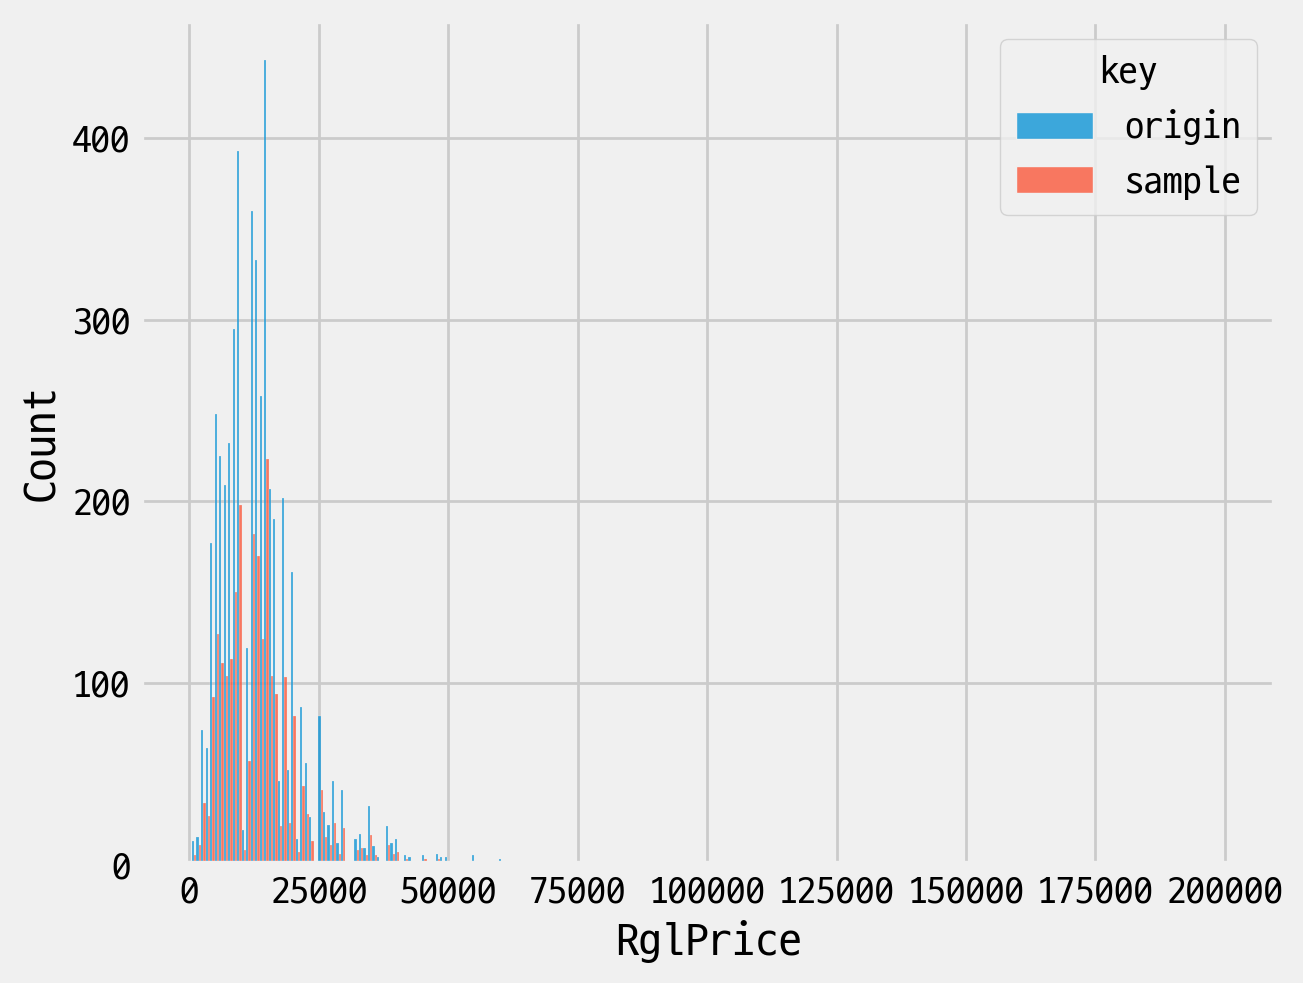

In [176]:
sampled_X, sampled_y = sample_data({'X':X_vld,'y':y_vld},0.5)

temp = pd.DataFrame(y_vld)
temp['key'] = 'origin'
temp2 = pd.DataFrame(sampled_y)
temp2['key'] = 'sample'
rslt = pd.concat([temp,temp2])
sns.histplot(rslt,x='RglPrice',hue='key',multiple='dodge')

#display(y_vld.describe())
#display(sampled_y.RglPrice.describe())

In [177]:
part_coeff = {
        'part' : [[0,5000],[17500,22500],[22500,27500],[27500,32500],[32500,42500],[42500,100000]],
        'coeff' : [2,2,4,8,25,50]
}
infm = 3000
supm = 80000
part_given = [x for x in part_coeff['part'] if x[1] > infm]
part_given = [x for x in part_given if x[0] <= supm]
front = [infm]+[x[0] for x in part_given]+[min(part_given[-1][1],supm)]
end = [max(infm,part_given[0][0])]+[x[1] for x in part_given]+[supm]
rates = [1]+part_coeff['coeff']+[1]

diff = np.array(end) - np.array(front)
if np.sum(diff < 0) > 0 :
        raise Exception('part define error')
diff = np.array(front[2:-1]) - np.array(end[1:-2])
print(front)
print(end)
print(diff)
if np.sum(diff < 0) > 0 : raise Exception('part define error')

[3000, 0, 17500, 22500, 27500, 32500, 42500, 80000]
[3000, 5000, 22500, 27500, 32500, 42500, 100000, 80000]
[12500     0     0     0     0]


In [178]:
sampled = dict()
ths = [5,50,500]
coeff = [2,1,0.2]
sample_rate = 0.15

part_info = {
        'part' : [[0,5000],[17500,22500],[22500,27500],[27500,32500],[32500,42500],[42500,100000]],
        'coeff' : [2,2,4,8,25,50]
}



for key,data in tqdm(slice_dict.items()):
    if len(data) < ths[0] : sampled[key] = data
    else:
        if len(data) < ths[1] : rate = sample_rate*coeff[0]
        elif len(data) > ths[-1] : rate = sample_rate*coeff[-1]
        else : rate = np.interp(len(data),ths,coeff)*sample_rate
         
        temp = {'X' : data[[x for x in data.columns if x!= 'Price']],
                'y':data['Price']}
        try : 
               X,y = sample_data(temp,rate,part_info)
        except :
                print(key,len(data))
                raise Exception()
        X['Price'] = y
        sampled[key] = X

  0%|          | 0/620 [00:00<?, ?it/s]

0.135242455859561


558

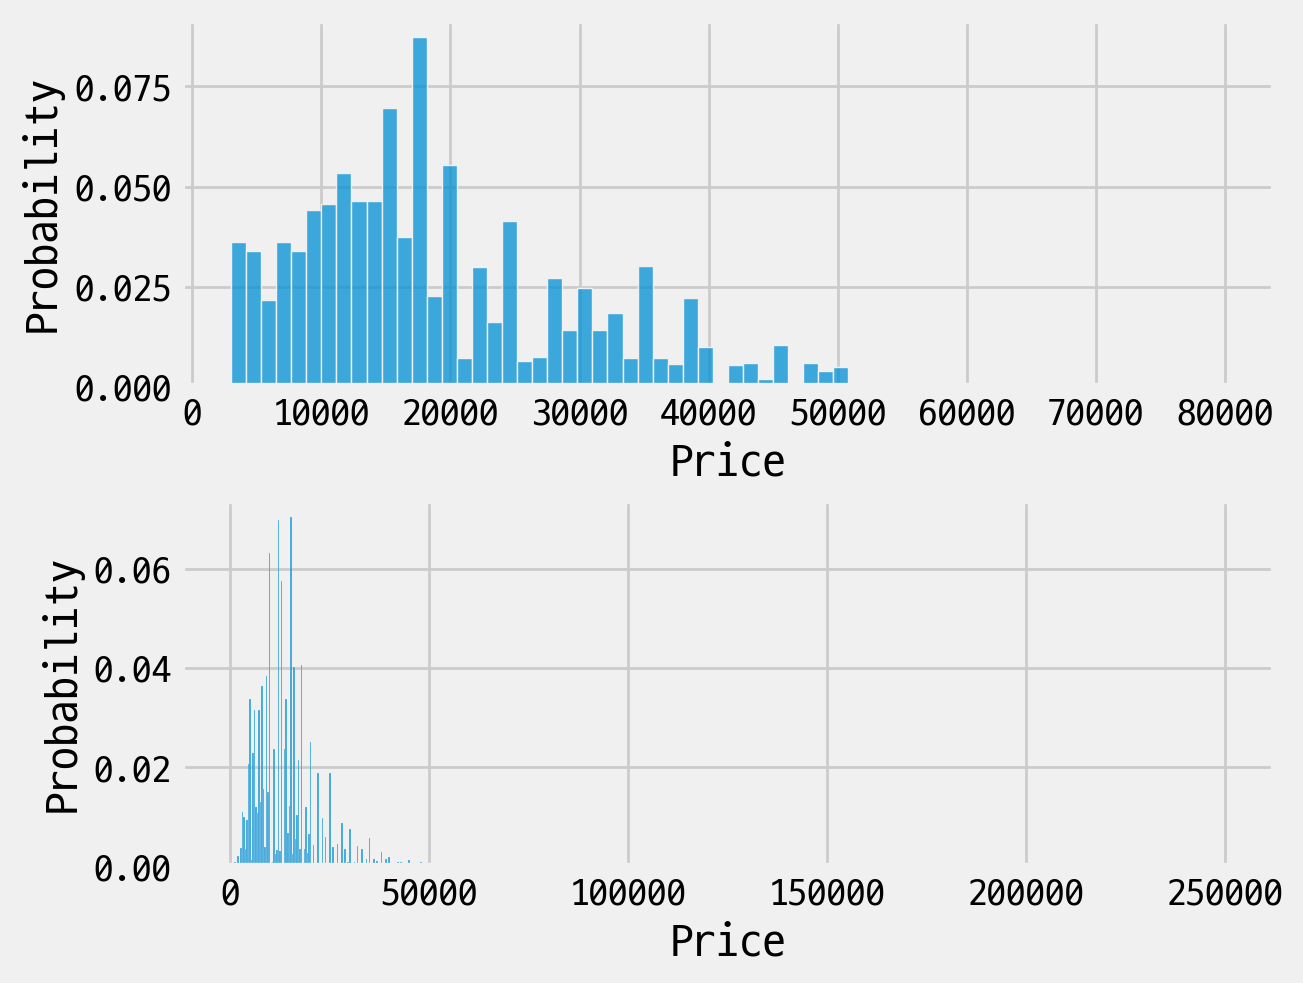

In [179]:
x_sample = pd.concat(sampled.values())
fig,ax = plt.subplots(2,1)
sns.histplot(x_sample,x='Price',ax=ax[0],stat='probability')
sns.histplot(df,x='Price',ax=ax[1],stat='probability')

print(len(x_sample)/len(df))
np.sum(x_sample['Price']>40000)

  0%|          | 0/620 [00:00<?, ?it/s]

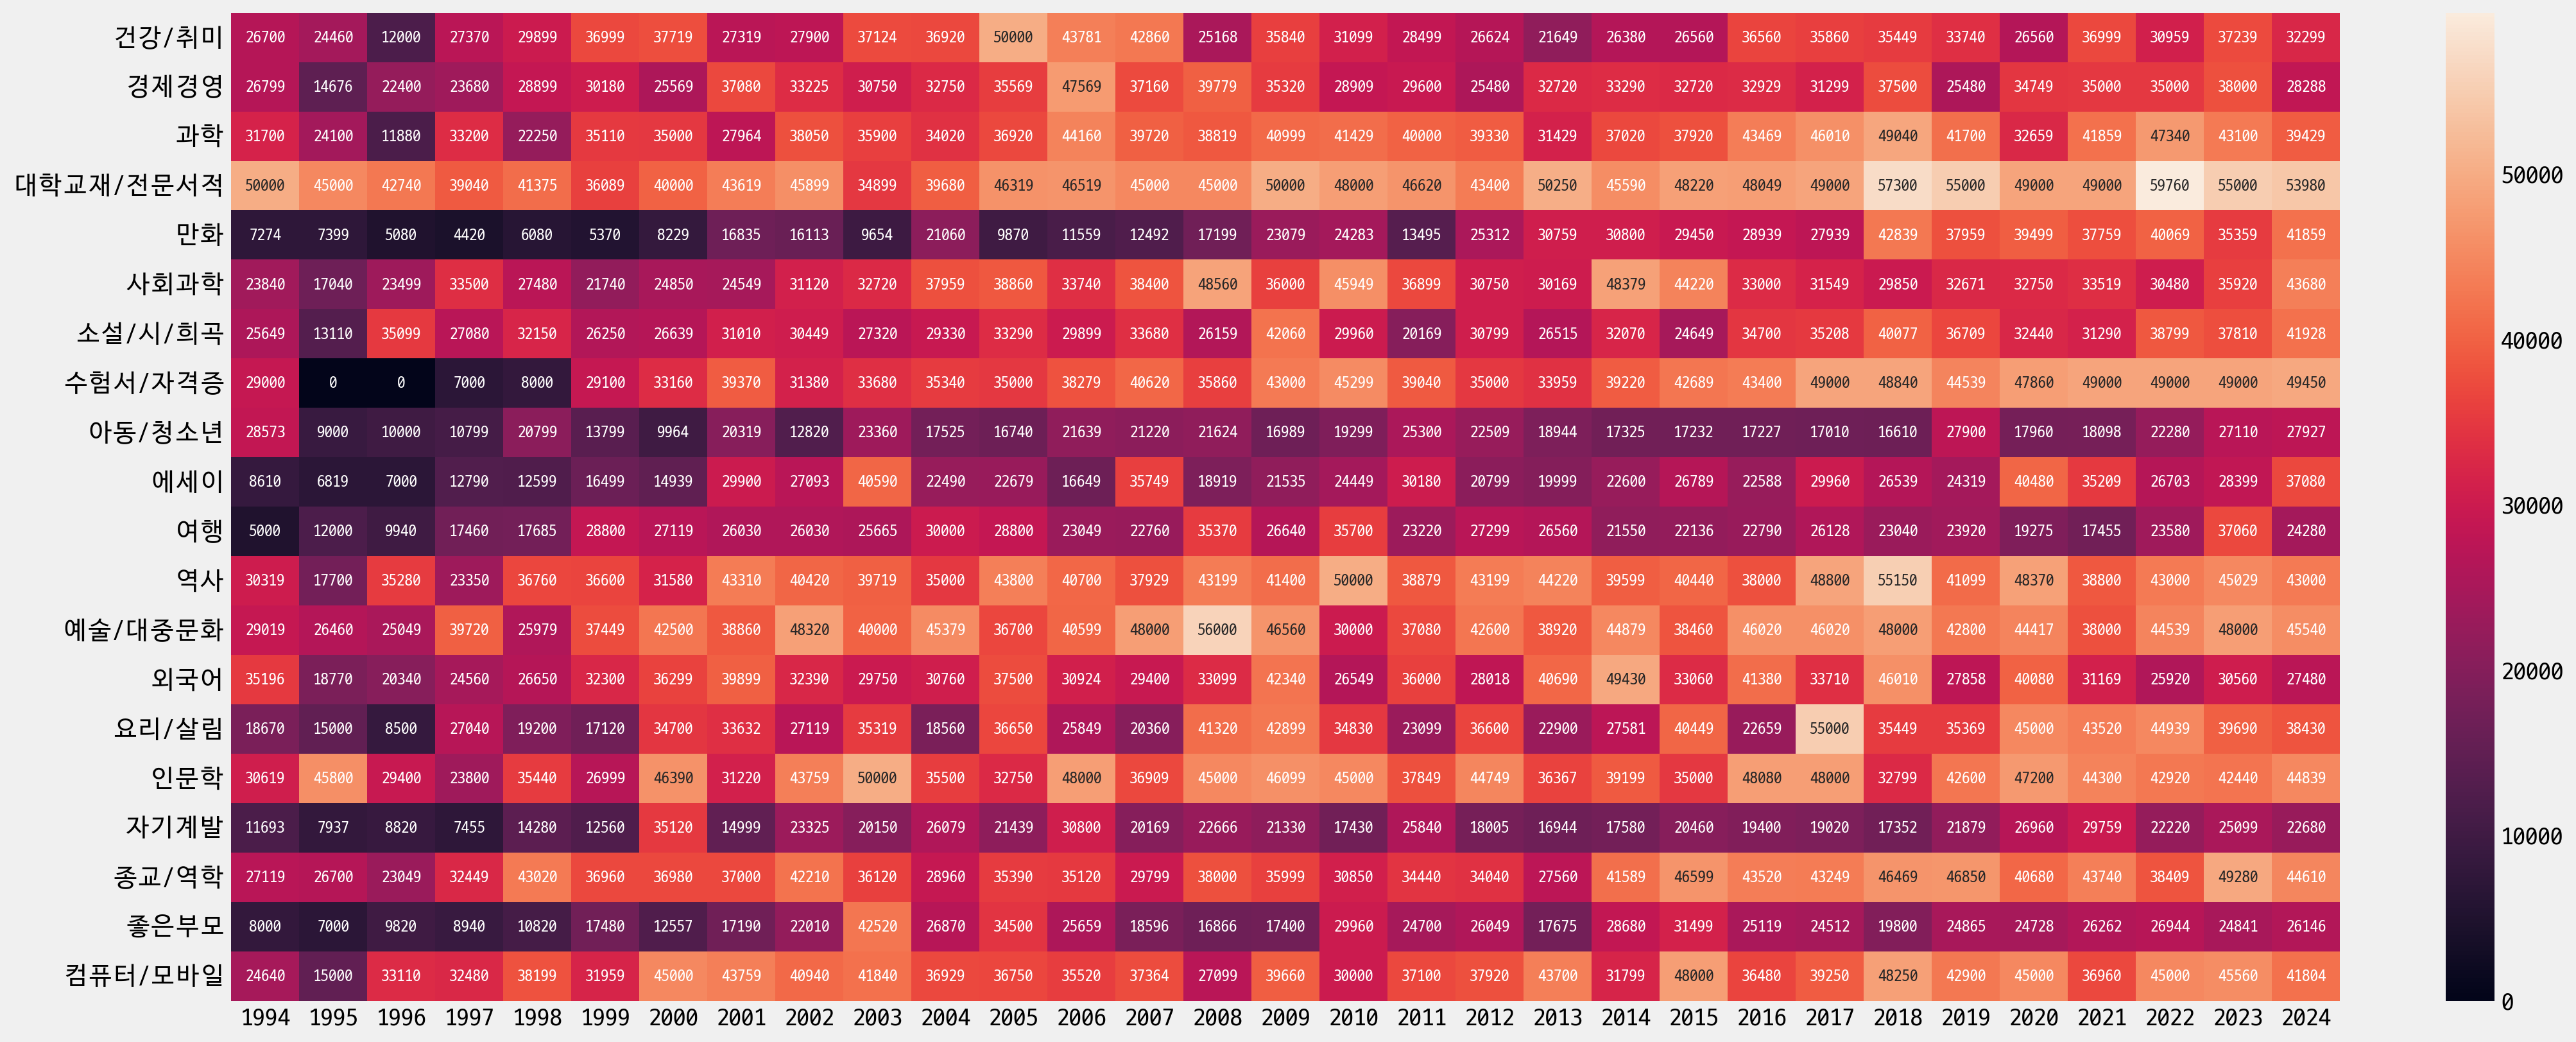

In [180]:
sliced2= statify_df(x_sample,cols)

rslt = defaultdict(lambda : defaultdict(int))

q = 0.03

for key,ele in sliced2.items():
    data = ele['data']['Price']
    if len(data) == 0 : content = 0
    else : content = np.quantile(data,1-q).astype(int)
    rslt[key[0]][key[1]] = content

fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

up_bnd = pd.DataFrame(rslt)

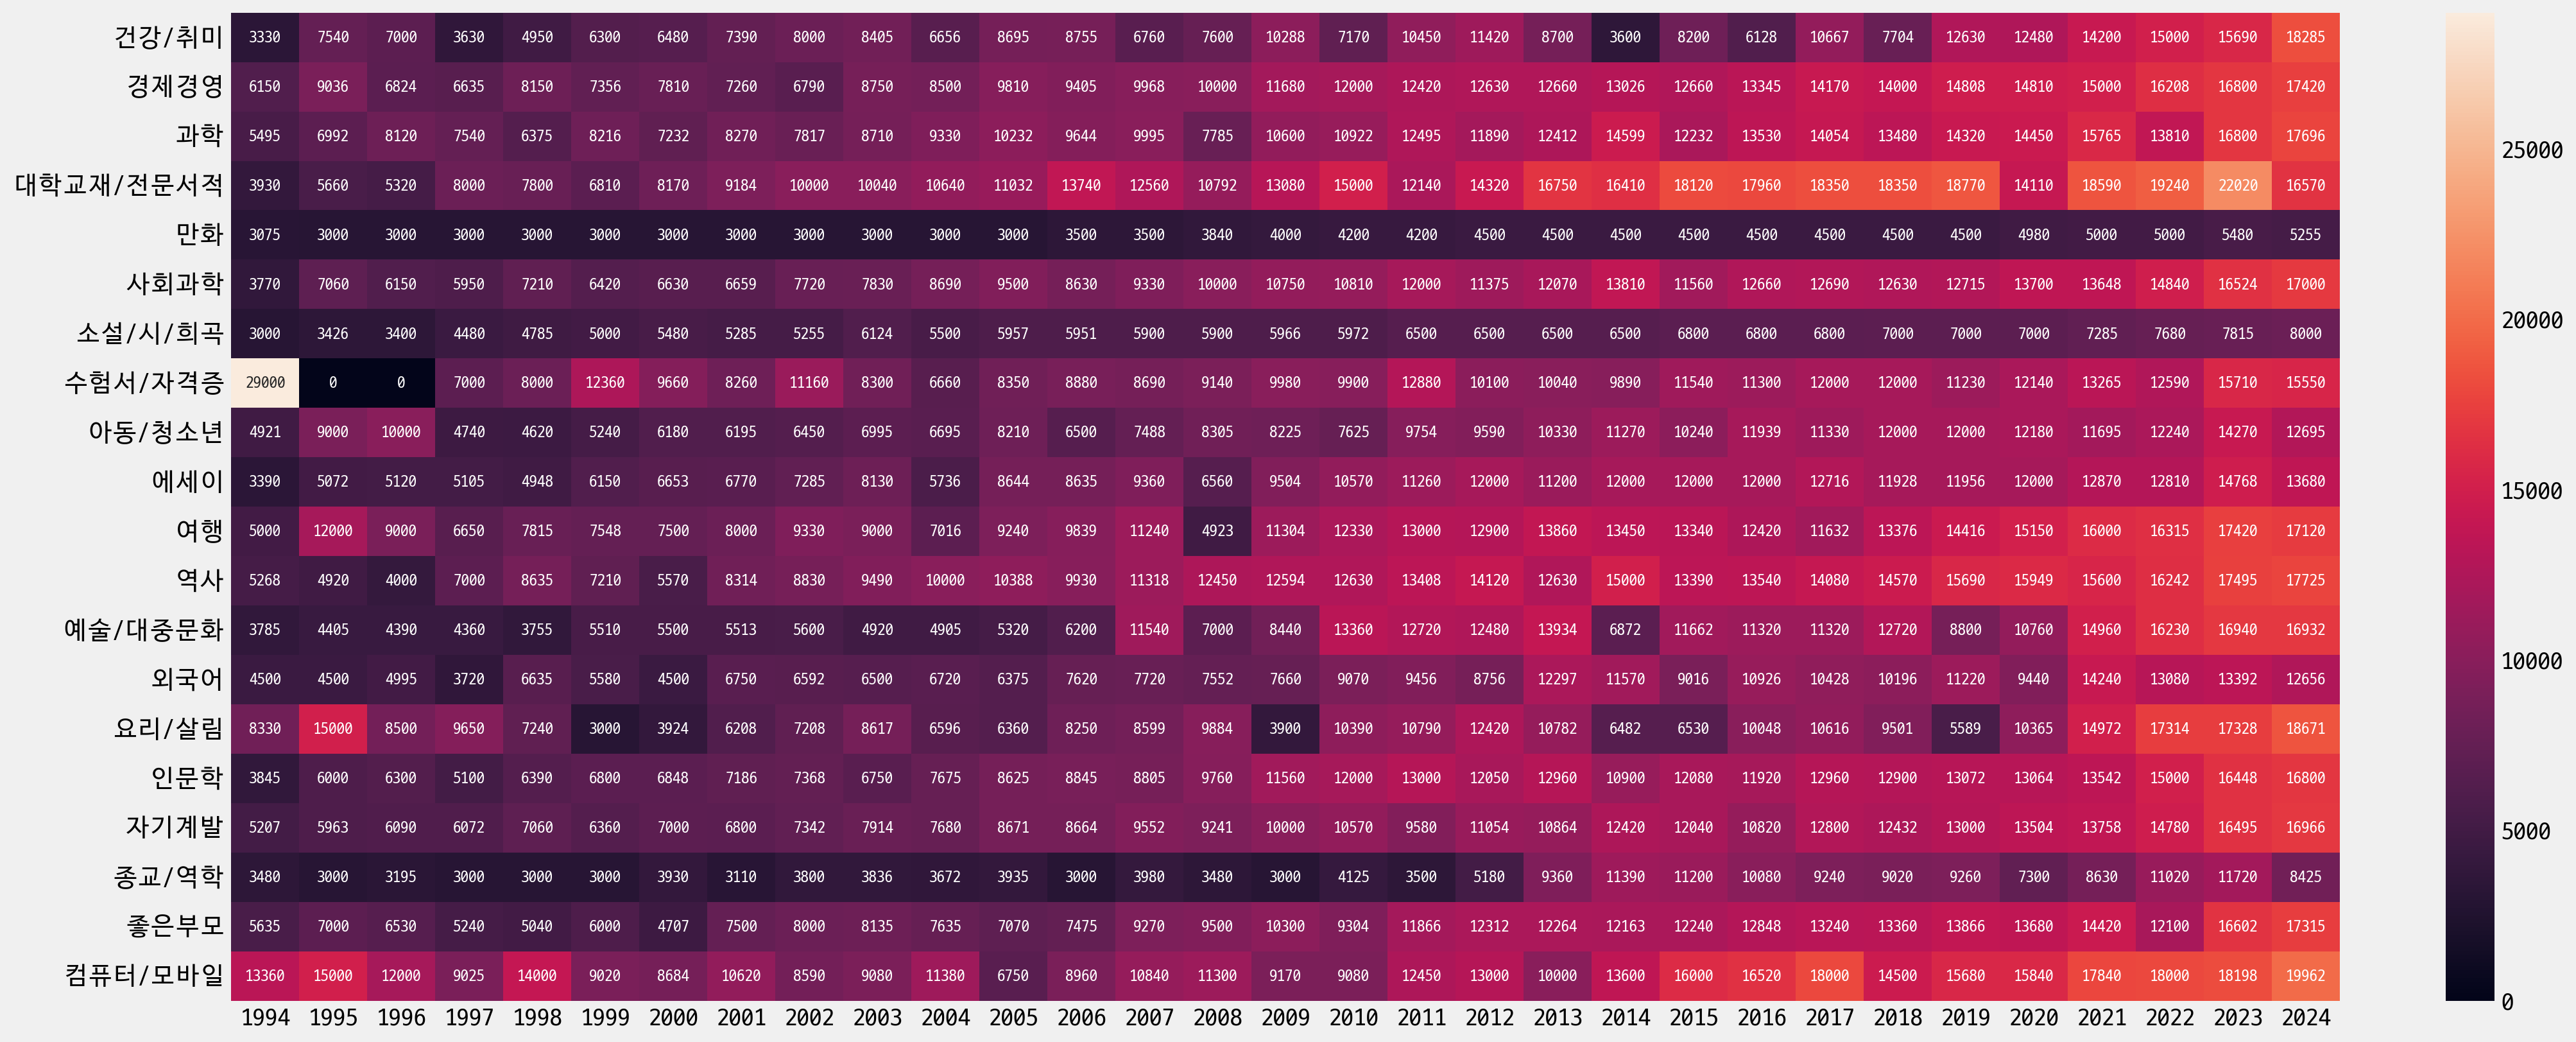

In [181]:
rslt = defaultdict(lambda : defaultdict(int))

q = 0.03

for key,ele in sliced2.items():
    data = ele['data']['Price']
    if len(data) == 0 : content = 0
    else : content = np.quantile(data,q).astype(int)
    rslt[key[0]][key[1]] = content

fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

lw_bnd = pd.DataFrame(rslt)

In [188]:
#bnd_diff = up_bnd-lw_bnd

ths_up = 45000 
ths_lw = 3000
#ths_diff = 10000

slice_dict2 = dict() 
ths_dict2= dict() 

for key,ele in sliced2.items():
    up, low = up_bnd.loc[key[1],key[0]],lw_bnd.loc[key[1],key[0]]
    #if up - low < ths_diff : 
    ths_dict2[key]={
        'up' : max(up,ths_up),
        'lw' : max(low,ths_lw),
    }
    
for key,ele in sliced2.items():
    data = ele['data']
    cond = (data['Price'] <= ths_dict2[key]['up']) & (data['Price']>= ths_dict2[key]['lw'])
    slice_dict2[key] = data[cond]

<Axes: >

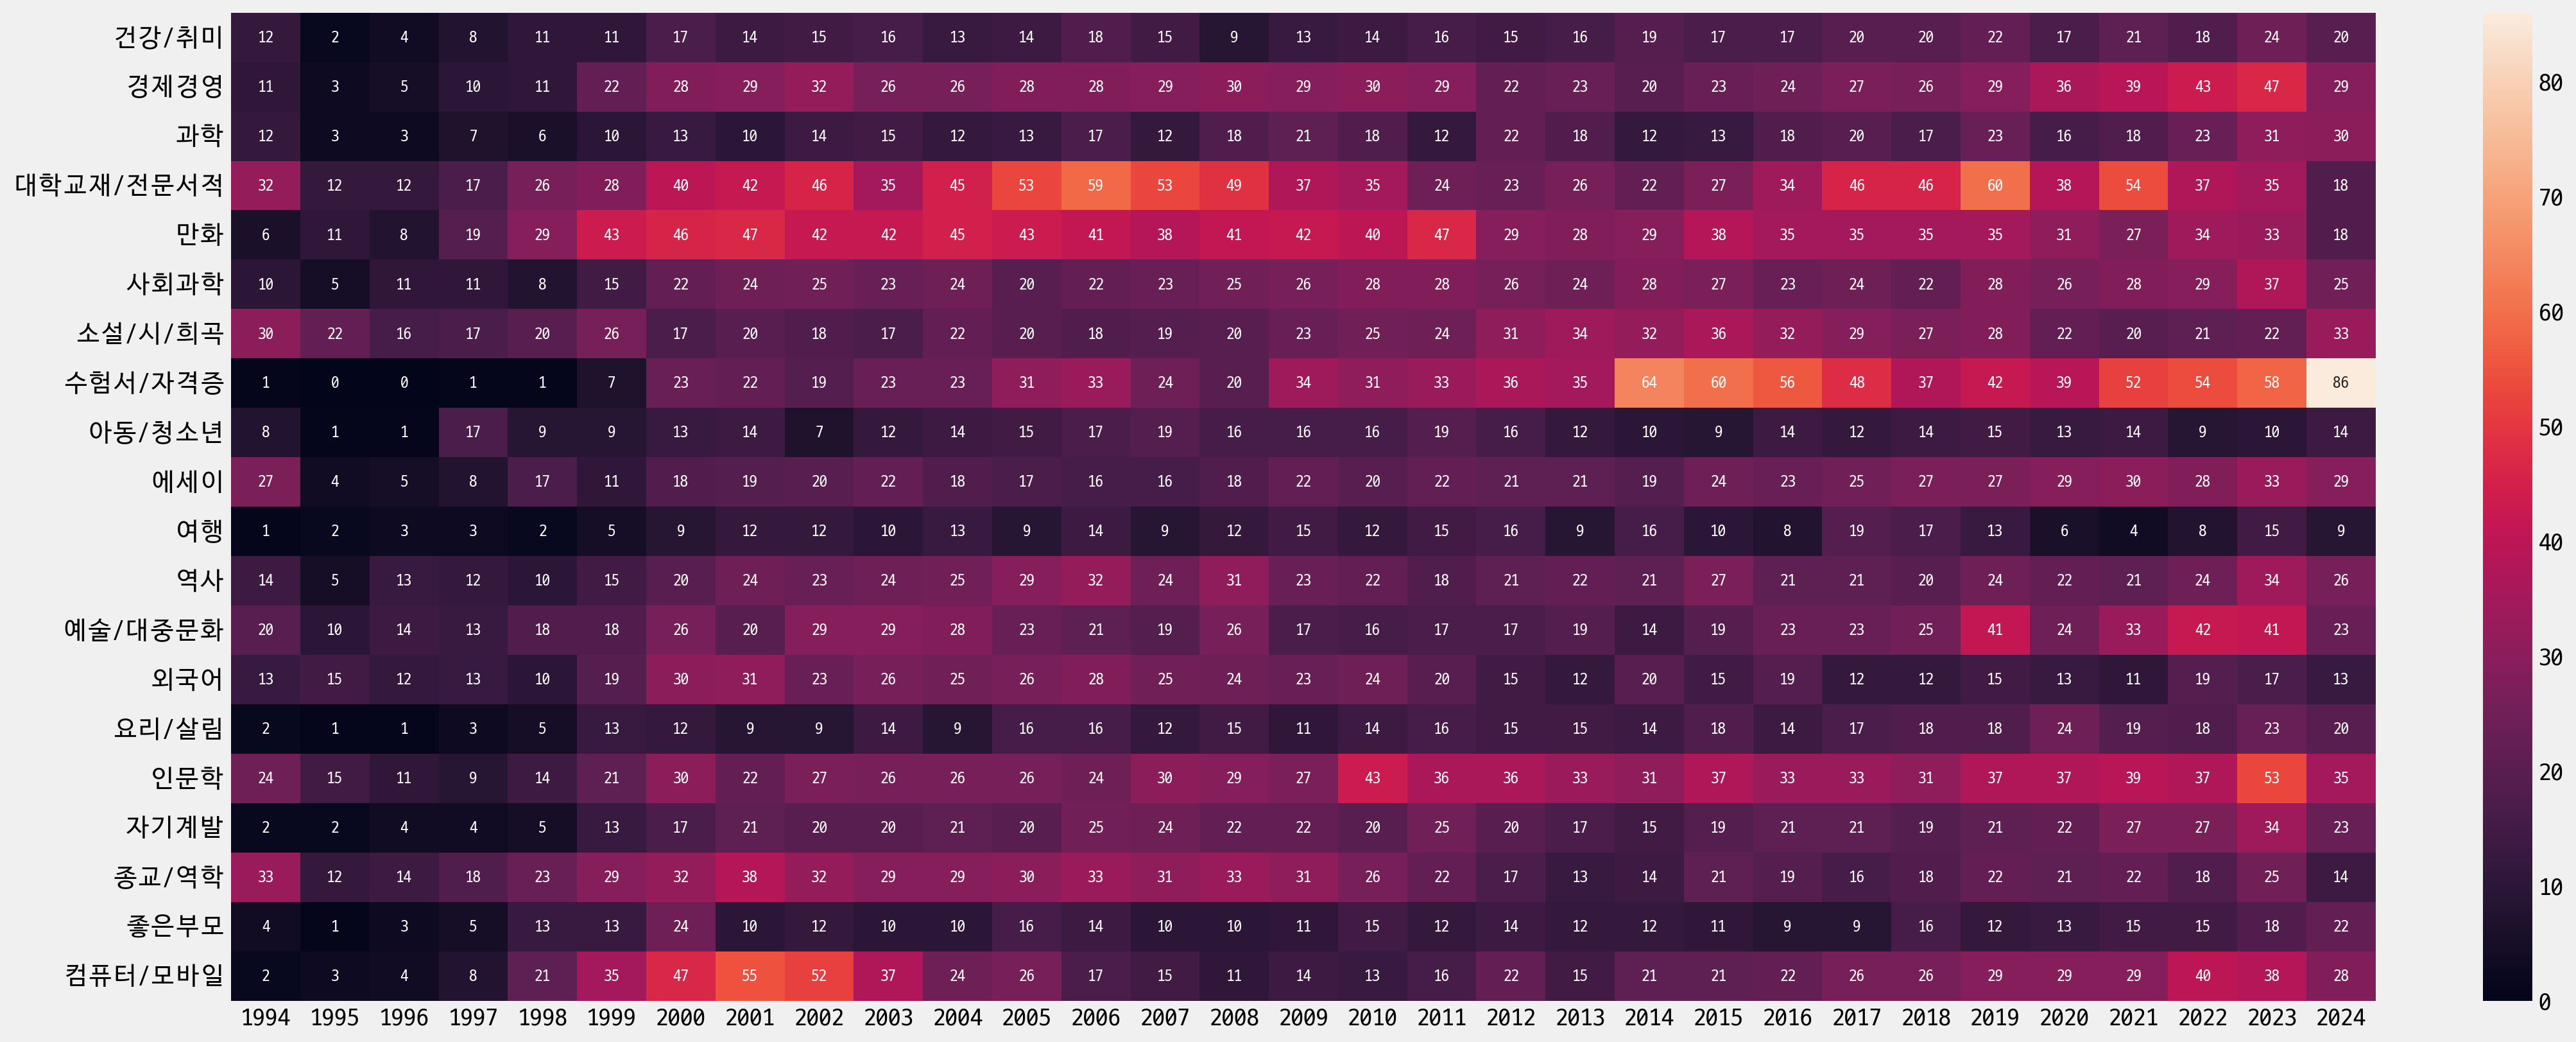

In [189]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))
for key,ele in sliced2.items():
    rslt[key[0]][key[1]] = len(ele['data'])
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

<Axes: >

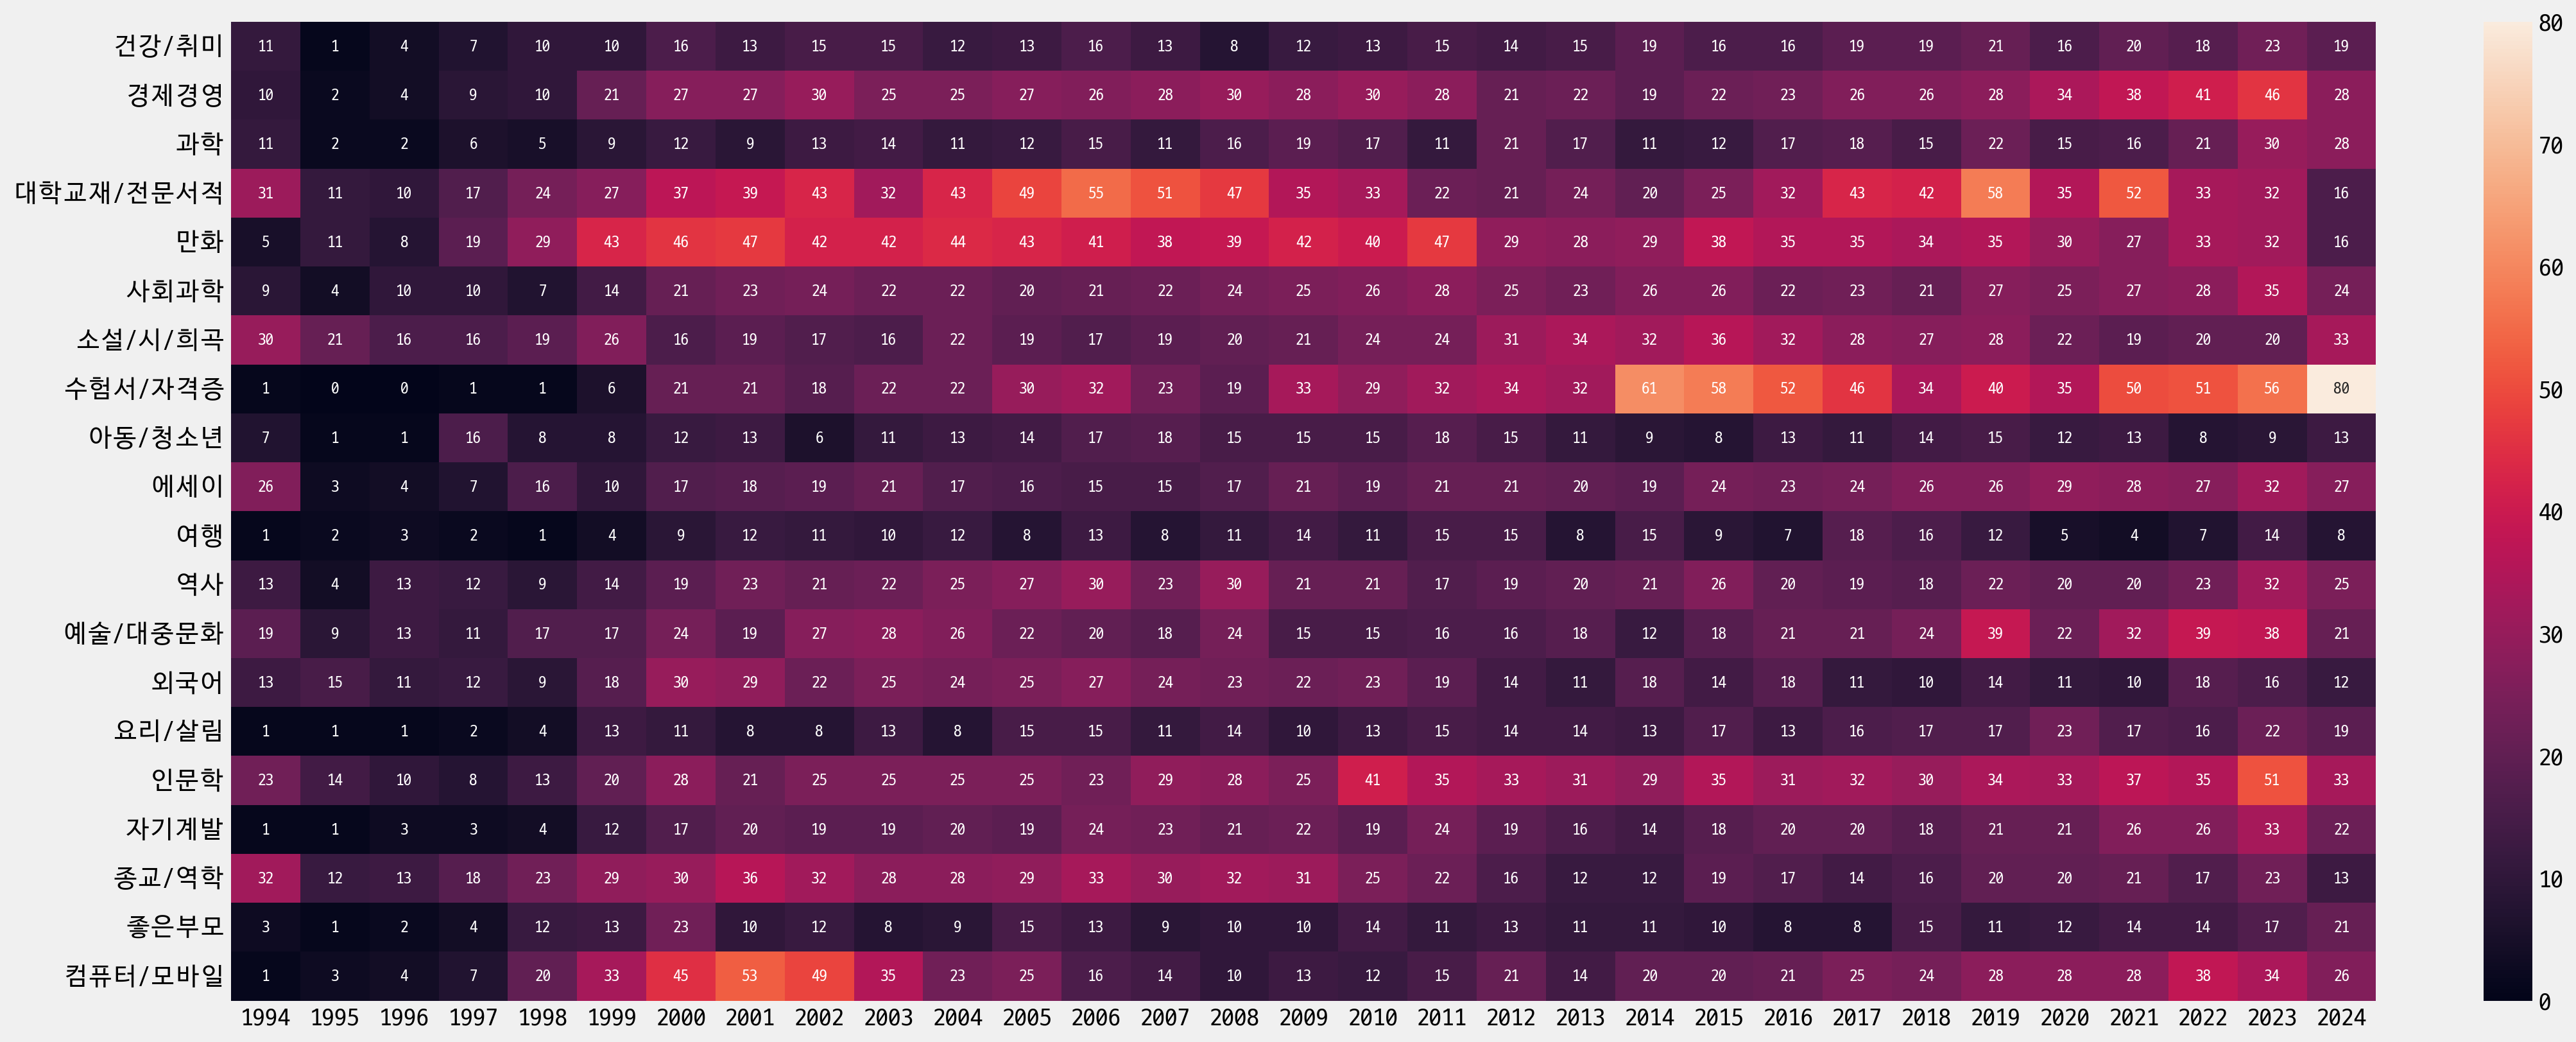

In [190]:
from collections import defaultdict

rslt = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict2.items():
    rslt[key[0]][key[1]] = len(ele)
    
    
fig, ax = plt.subplots(figsize=(20,8)) 
sns.heatmap(pd.DataFrame(rslt),annot=True,annot_kws={'fontsize':9},fmt='d',ax=ax)

0 13.0 19.0 27.0 80
-8.0 48.0


12662

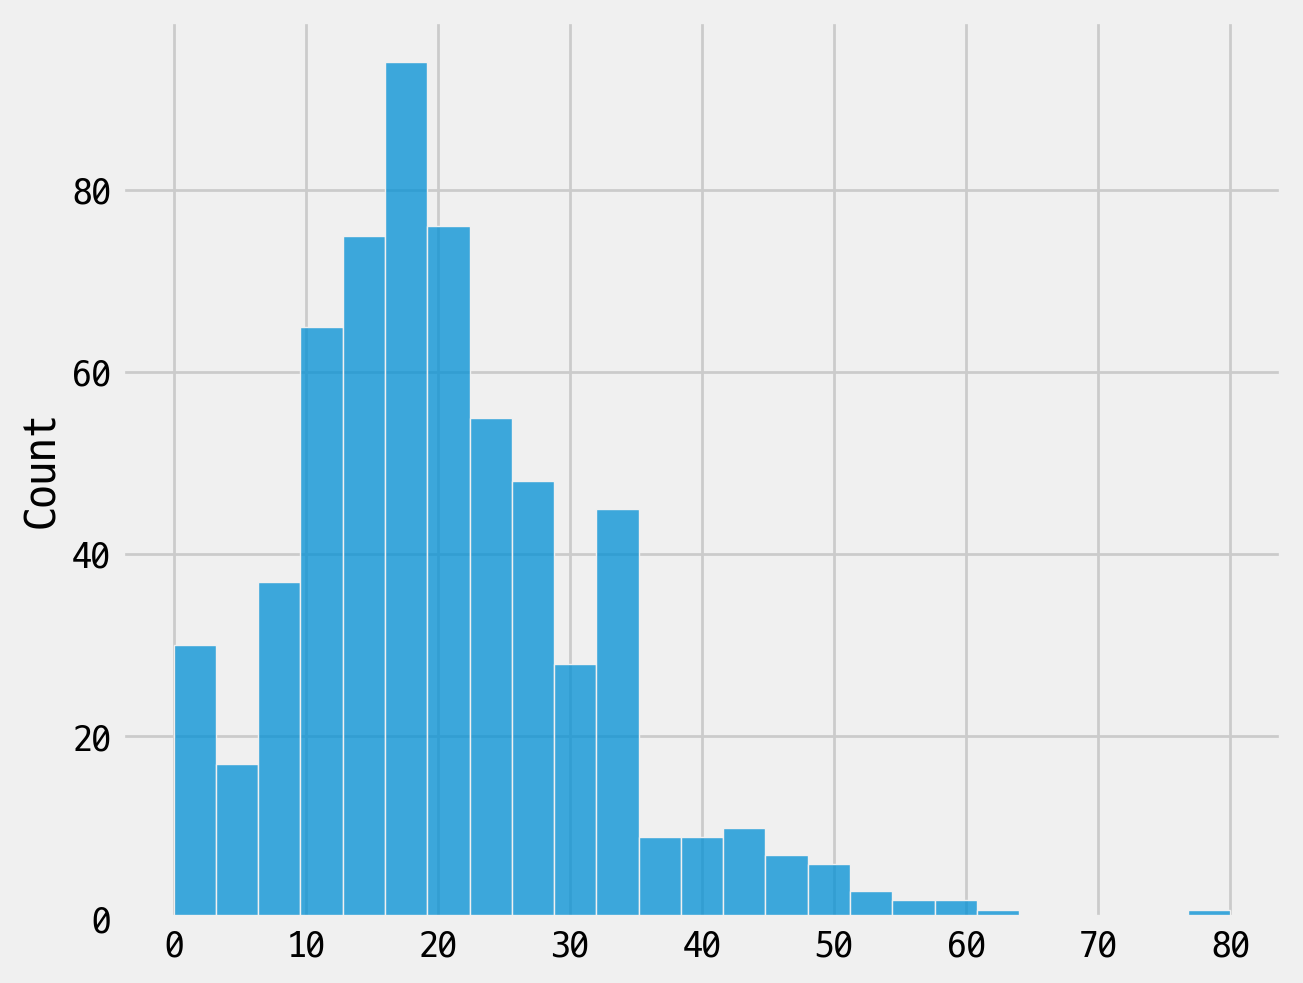

In [191]:
lens = pd.DataFrame(rslt).values.reshape(-1)
sns.histplot(lens)

q1 = np.quantile(lens,1/4)
q2 = np.quantile(lens,2/4)
q3 = np.quantile(lens,3/4)
print(min(lens),q1,q2,q3,max(lens))
iqr = q3-q1
print(q1-1.5*iqr,q3+1.5*iqr)
sum(lens)

0.13973959096522995
0.13252810282388897
558
427


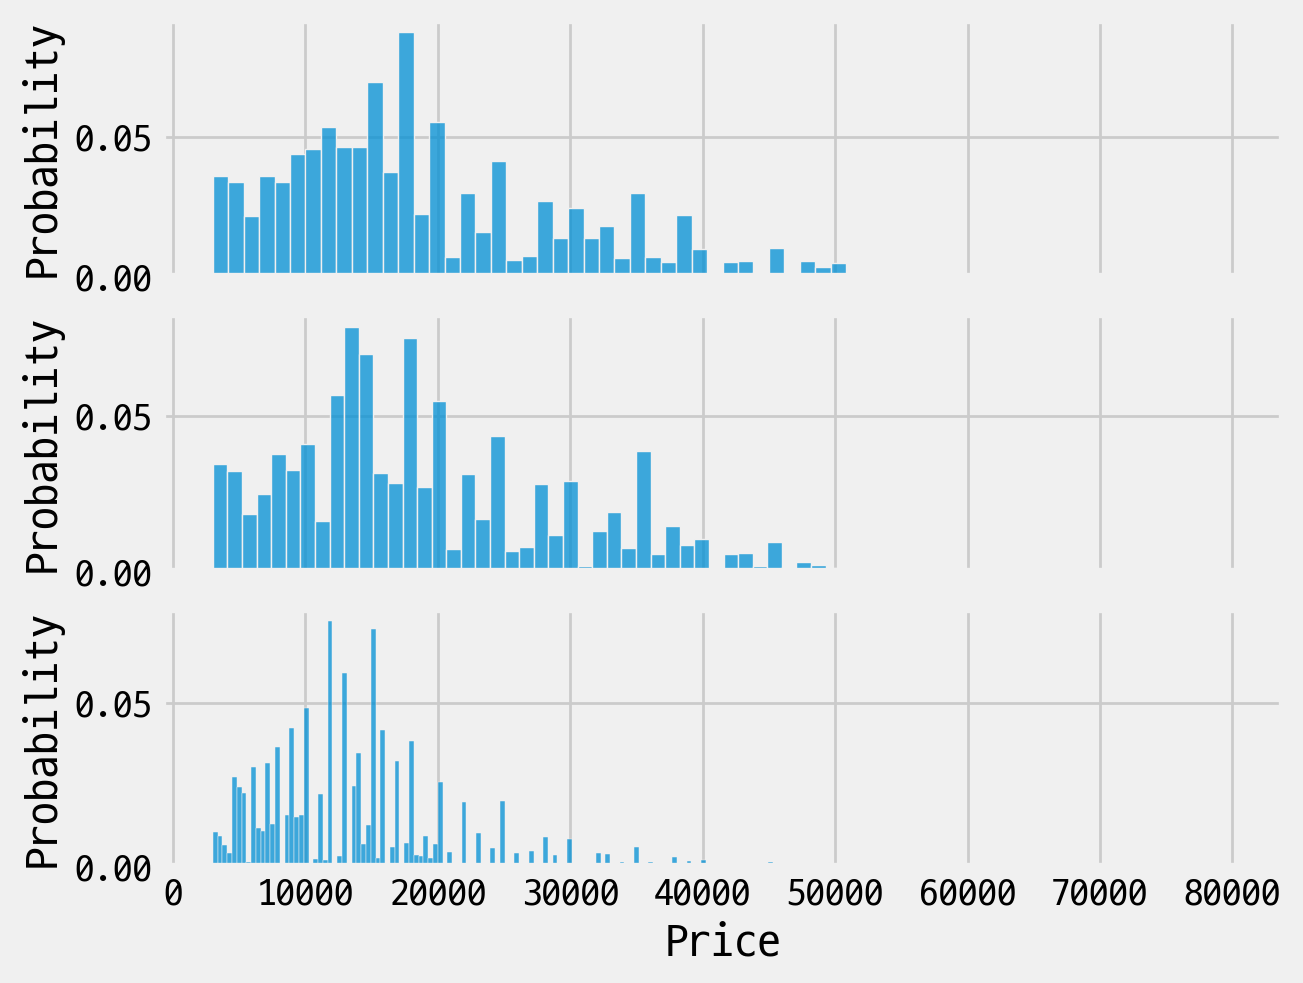

In [192]:
x_sample0 = pd.concat(slice_dict.values())
x_sample1 = pd.concat(sampled.values())
x_sample2 = pd.concat(slice_dict2.values())
fig,ax = plt.subplots(3,1,sharex=True)
sns.histplot(x_sample1,x='Price',ax=ax[0],stat='probability')
sns.histplot(x_sample2,x='Price',ax=ax[1],stat='probability')
sns.histplot(x_sample0,x='Price',ax=ax[2],stat='probability')

print(len(x_sample1)/len(x_sample0))
print(len(x_sample2)/len(x_sample0))
print(np.sum(x_sample['Price']>40000))
print(np.sum(x_sample2['Price']>40000))

|    |    0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    17 |    18 |    19 |    20 |    21 |    22 |    23 |    24 |    25 |
|---:|-----:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 | 2500 |  5000 |  7500 | 10000 | 12500 | 15000 | 17500 | 20000 | 22500 | 25000 | 27500 | 30000 | 32500 | 35000 | 37500 | 40000 | 42500 | 45000 | 47500 | 50000 | 52500 | 55000 | 57500 | 60000 | 65000 | 80000 |
|  1 | 5555 | 12646 | 13459 | 14209 | 13534 | 14863 |  6798 |  4833 |  1730 |  2720 |  1346 |  1235 |   520 |   819 |   470 |   295 |   115 |   163 |   139 |    69 |     5 |    13 |     2 |     2 |     1 |     1 |
|    |    0 |    1 |    2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    1

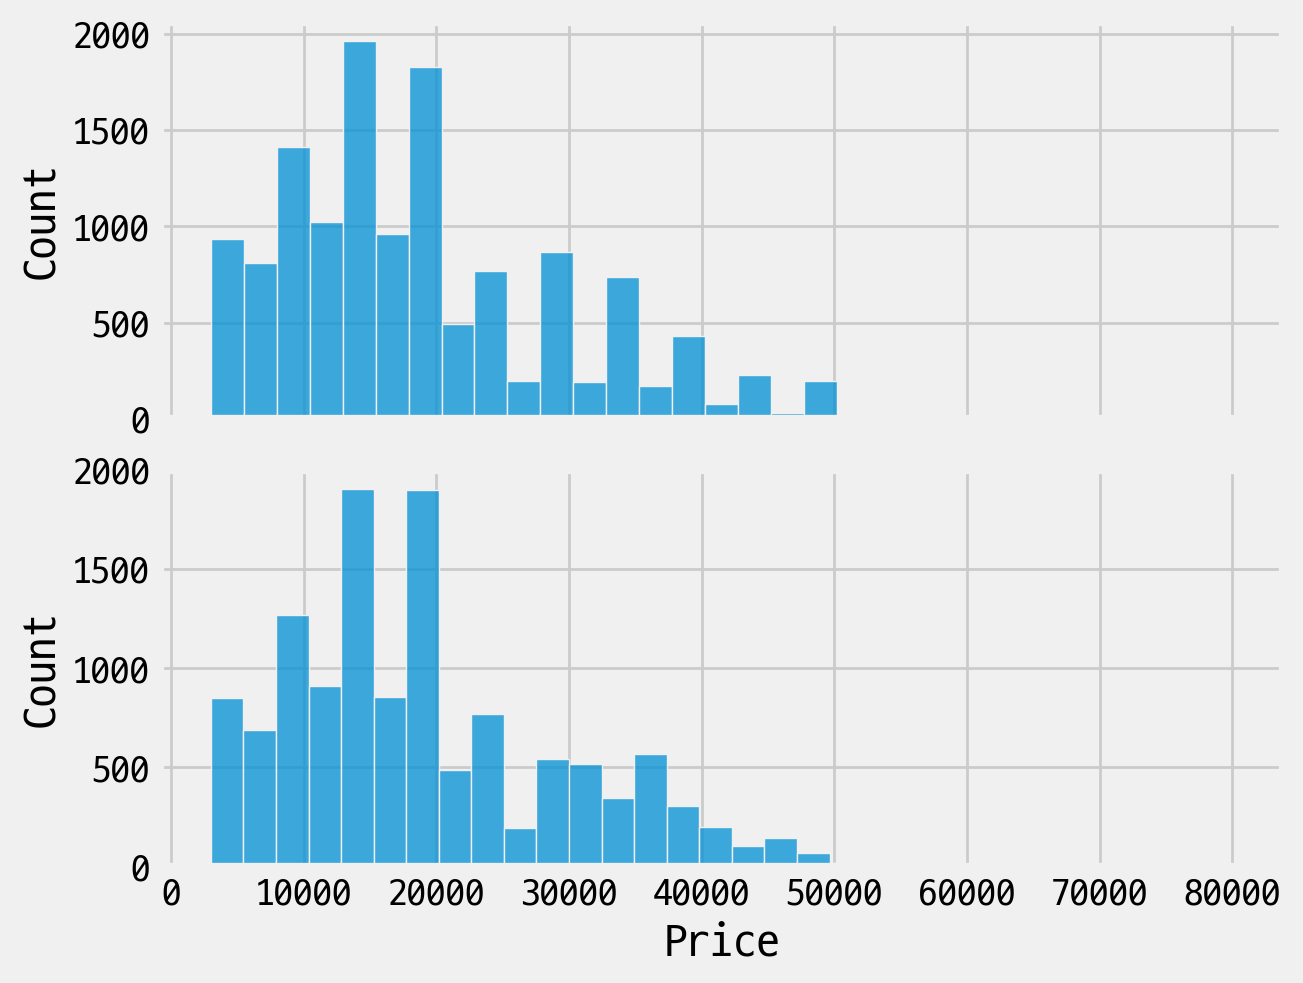

In [193]:
fig,ax2 = plt.subplots(2,1,sharex=True)
sns.histplot(x_sample1,x='Price',ax=ax2[0],binwidth=2500)
sns.histplot(x_sample2,x='Price',ax=ax2[1],binwidth=2500)

print(pd.DataFrame(np.unique((x_sample0['Price']//2500)*2500,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample1['Price']//2500)*2500,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample2['Price']//2500)*2500,return_counts=True)).to_markdown())

|    |     0 |     1 |     2 |     3 |     4 |     5 |     6 |     7 |     8 |     9 |    10 |    11 |    12 |    13 |    14 |    15 |    16 |    17 |    18 |    19 |    20 |    21 |    22 |    23 |    24 |    25 |    26 |    27 |    28 |    29 |    30 |    31 |    32 |    33 |    34 |    35 |
|---:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
|  0 | 25000 | 26000 | 27000 | 28000 | 29000 | 30000 | 31000 | 32000 | 33000 | 34000 | 35000 | 36000 | 37000 | 38000 | 39000 | 40000 | 41000 | 42000 | 43000 | 44000 | 45000 | 46000 | 47000 | 48000 | 49000 | 50000 | 51000 | 52000 | 53000 | 55000 | 56000 | 57000 | 58000 | 60000 | 67000 | 80000 |
|  1 |   426 |    81 |   109 |   349 |   185 |   326 |    24 |   170 |   242 |    98 |   399 |    93 |    74 |   19

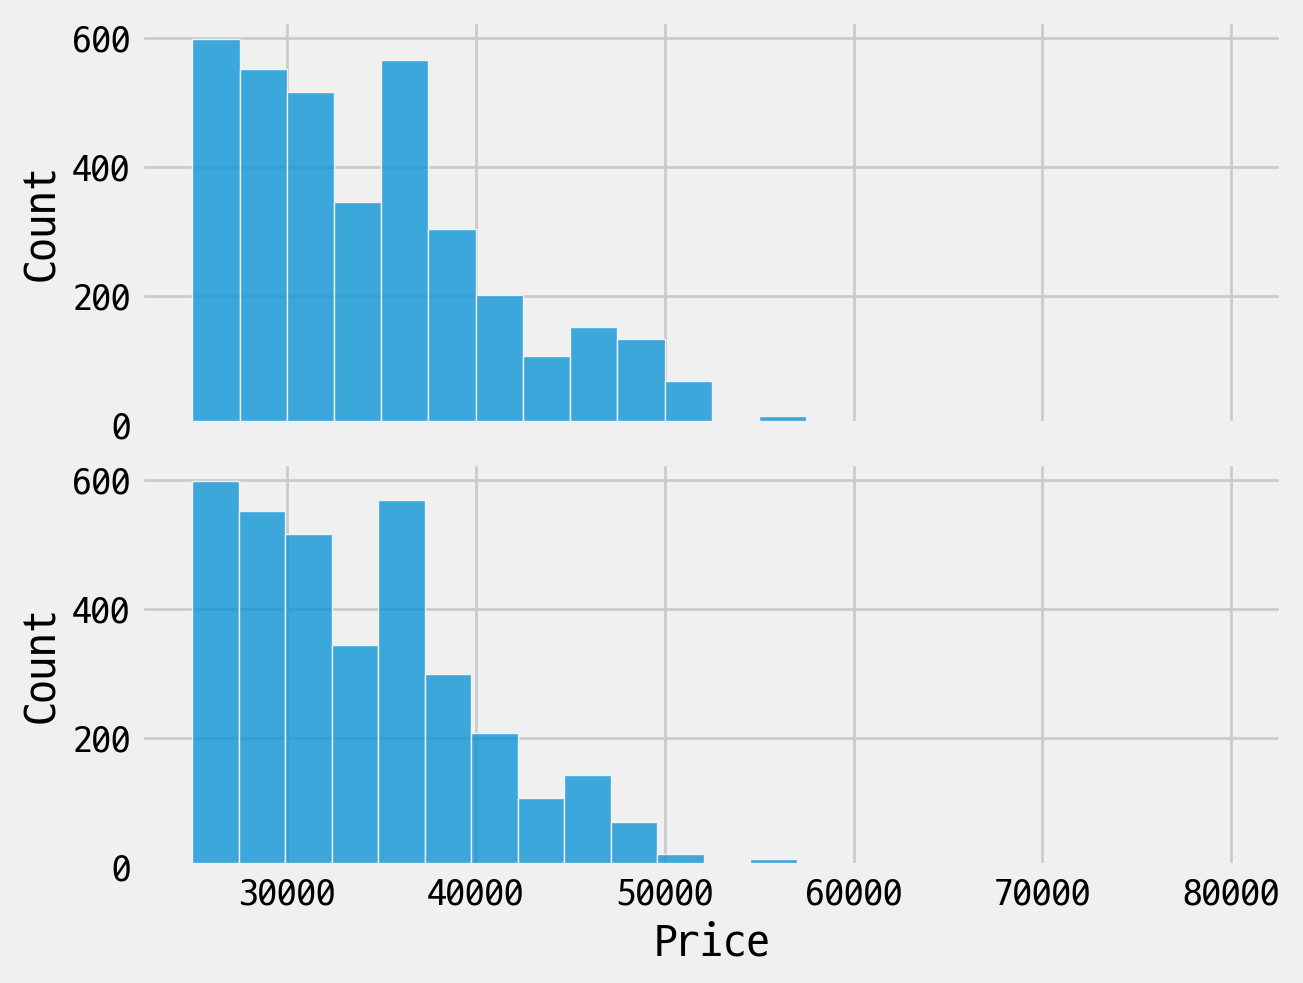

In [197]:
fig,ax2 = plt.subplots(2,1,sharex=True)
x_sample12 =x_sample1[x_sample1['Price']>=25000]
x_sample22 =x_sample2[x_sample2['Price']>=25000]

sns.histplot(x_sample12,x='Price',ax=ax2[0],binwidth=2500)
sns.histplot(x_sample22,x='Price',ax=ax2[1],binwidth=2500)

print(pd.DataFrame(np.unique((x_sample12['Price']//1000)*1000,return_counts=True)).to_markdown())
print(pd.DataFrame(np.unique((x_sample22['Price']//1000)*1000,return_counts=True)).to_markdown())

In [194]:
display(x_sample0.Price.describe())
display(x_sample1.Price.describe())
display(x_sample2.Price.describe())

count    95542.000000
mean     13657.270206
std       7264.836510
min       3000.000000
25%       8500.000000
50%      13000.000000
75%      16800.000000
max      80000.000000
Name: Price, dtype: float64

count    13351.000000
mean     18913.819190
std      10777.202949
min       3000.000000
25%      11000.000000
50%      16800.000000
75%      25000.000000
max      80000.000000
Name: Price, dtype: float64

count    12662.000000
mean     19011.656926
std      10388.176325
min       3000.000000
25%      12000.000000
50%      17000.000000
75%      25000.000000
max      57000.000000
Name: Price, dtype: float64

In [77]:
answer_sheet = defaultdict(lambda : defaultdict(int))
for key,ele in sampled.items():
    answer_sheet[key[0]][key[1]] = np.median(ele['Price']) if len(ele)> 2 else np.nan
    
answer_sheet = pd.DataFrame(answer_sheet)
answer_sheet = answer_sheet.ffill(axis=1)
answer_sheet = answer_sheet.bfill(axis=1)

answer_sheet.to_dict()

cheat=dict()
for k1,ele in answer_sheet.to_dict().items():
    for k2,val in ele.items():
        cheat[f'{k1}|{k2}']=val

y_prd = cheat_sheet(X_vld,cheat,cols)
print(r2_score(y_vld,y_prd),mape(y_vld,y_prd),rmse(y_vld,y_prd))
y_prd = cheat_sheet(X_tst,cheat,cols)
print(r2_score(y_tst,y_prd),mape(y_tst,y_prd),rmse(y_tst,y_prd))

0.3279202083245938 0.308031833243903 6832.500258112131
0.33557661208861367 0.30781421854145274 6616.810647452922


In [78]:
answer_sheet = defaultdict(lambda : defaultdict(int))
for key,ele in slice_dict2.items():
    answer_sheet[key[0]][key[1]] = np.median(ele['Price']) if len(ele)> 2 else np.nan
    
answer_sheet = pd.DataFrame(answer_sheet)
answer_sheet = answer_sheet.ffill(axis=1)
answer_sheet = answer_sheet.bfill(axis=1)

answer_sheet.to_dict()

cheat=dict()
for k1,ele in answer_sheet.to_dict().items():
    for k2,val in ele.items():
        cheat[f'{k1}|{k2}']=val

y_prd = cheat_sheet(X_vld,cheat,cols)
print(r2_score(y_vld,y_prd),mape(y_vld,y_prd),rmse(y_vld,y_prd))
y_prd = cheat_sheet(X_tst,cheat,cols)
print(r2_score(y_tst,y_prd),mape(y_tst,y_prd),rmse(y_tst,y_prd))

0.3375728502558194 0.319313271977986 6783.257444641453
0.3459102628720362 0.3195614667458617 6565.154009137585


In [42]:
#apply tokenizer
cols_freq = ['Author','Publshr']

In [26]:
#아래 ths 는 EDA 결과 제가 자의적으로 정한 내용
bookinfo = data_dict['trn']['X']
ths_author = int(np.round(len(bookinfo)/500)*75)
ths_publshr = int(np.round(len(bookinfo)/500)*5)

map_author_encode = make_author_encode_map(bookinfo[['Author','SalesPoint']],ths_author)
map_publshr_encode = make_publshr_encode_map(bookinfo['Publshr'],ths_publshr)

encode_maps = {
    'Author' : lambda x : encode_tokens(map_author_encode,x,oov=False),
    'Publshr' : lambda x : encode_tokens(map_publshr_encode,x,oov=False),
}

In [27]:
for mode,data in data_dict.items():
    for col in tqdm(cols_freq):
        data['X'][col] = data['X'][col].map(encode_maps[col]).astype(str)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 38.50it/s]


In [28]:
data_dict['trn']['X'].head()

,BName,BName_sub,Author,Publshr,Author_mul,Pdate,SalesPoint,Category
84226,2013 최신시사상식 162집,NaN,0,38,False,20130715,223,수험서/자격증
82296,엿보는 고헤이지,NaN,0,185,True,20130329,304,소설/시/희곡
120256,한국 요괴 도감,NaN,0,14,False,20190321,3564,인문학
91927,마스카 애장판 9,NaN,0,3,False,20151102,316,만화
145531,안전하고 친절한 블록체인 안내서,NaN,0,0,False,20231120,758,경제경영


In [37]:
bk_info['Author_code'] = data_dict['trn']['X']['Author']
bk_info['Publshr_code'] = data_dict['trn']['X']['Publshr']

df_temp = bk_info[bk_info['Category'] == '고전']
display(df_temp.Author_code.value_counts())
np.mean(df_temp.Author_code == '0'),np.mean(bk_info.Author_code=='0')
display(np.mean(df_temp.loc[df_temp.Author_code == '0','Price']))
display(np.mean(df_temp.loc[df_temp.Author_code != '0','Price']))
display(np.unique(df_temp.Author,return_counts=True))


Author_code
0       120
447       7
209       5
967       4
946       2
1017      2
453       2
1495      1
1195      1
1297      1
541       1
452       1
49        1
Name: count, dtype: int64

13621.666666666666

16185.714285714286

(array(['간호윤', '강신웅', '교수신문', '권영한', '귀곡자', '그림 형제', '김달진', '김담구', '김만중',
        '김봉곤', '김부식', '김성중', '김시습', '김영수', '김용택', '김원중 편저자', '김쟁원', '김풍기',
        '김화경', '남영로', '노병천', '레오 니콜라예비치 톨스토이', '마르코 폴로', '마리온 기벨', '마이클 탕',
        '모리야 히로시', '몽테뉴', '미리내공방', '민영환', '박건영.이원규', '박기봉', '박명희', '박지원',
        '반덕진', '버나드 맨더빌', '버지니아 울프', '범립본 원저', '보카치오', '북앤북 편집부', '사마천',
        '샤론 르벨', '서정기', '성백효', '성현', '소포클레스', '손종섭', '송재소', '송철규',
        '슈테판 츠바이크', '신광한', '신동흔', '신유한', '아담 스미스', '아리스토텔레스', '아리스토파네스',
        '아이스킬로스ㆍ소포클레스', '야마구치 히사카즈', '양자오', '어니스트 톰슨 시튼', '에우리피데스', '오현리',
        '유몽인', '유의경', '유향', '이강옥 엮어옮김', '이규보', '이덕무', '이병혁', '이수광', '이순신',
        '이승수', '이승수.서신혜', '이언진', '이우성', '이응백', '이익', '이인호', '이중환', '이형식',
        '이혜구', '임시종', '임형택', '장연', '전국한문교사모임', '정민', '정범진', '정약용',
        '정재서.한형조.이재민', '조경남', '조나단 스위프트', '조수삼', '조위', '죠제프 베디에', '천갑녕',
        '최근덕', '최석기', '최인욱', '최철', '추적', '한비자', '허경진', '허명규', '허성도', '허웅',
        '혜초', '호메로스', '홍경호', '홍길주', '홍대용', '홍순명',

/tmp/ipykernel_2135/2887848769.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temp['check'] = df_temp['Author_code']=='0'


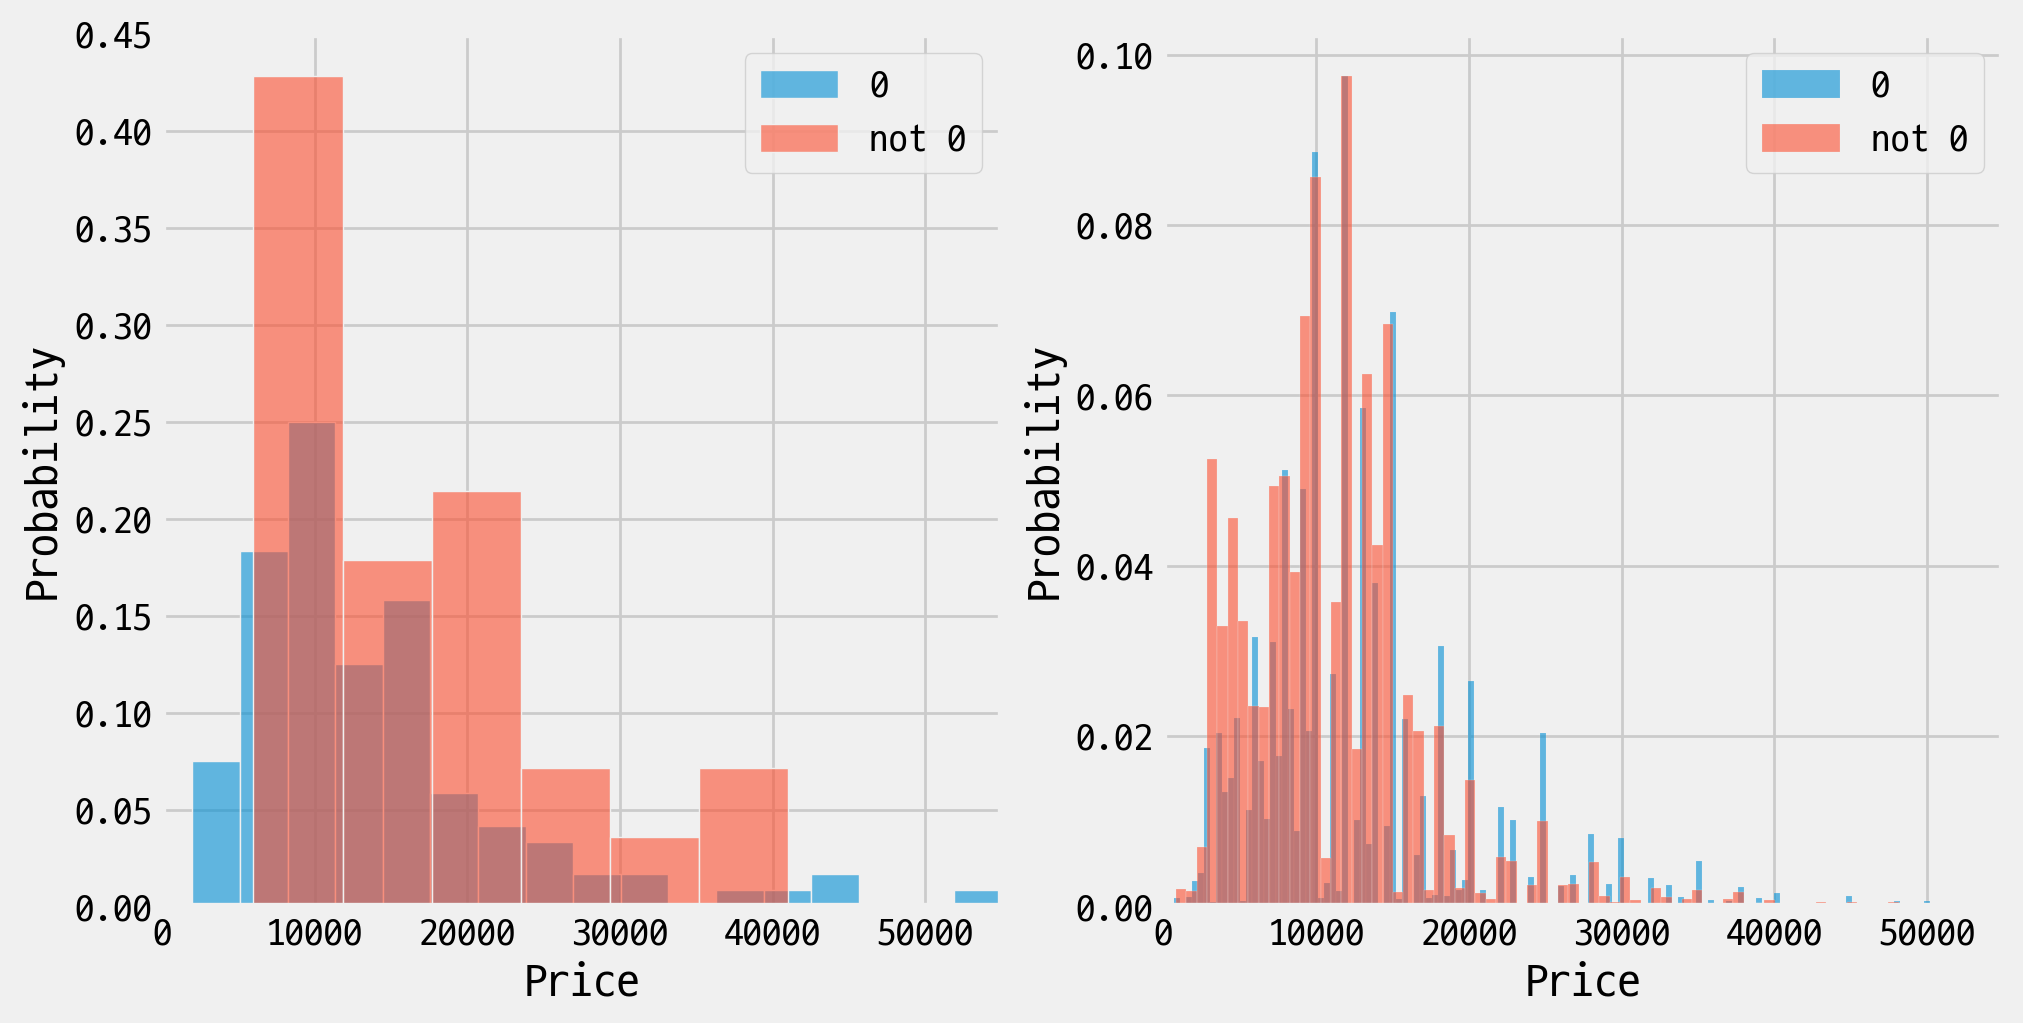

In [43]:
df_temp = bk_info[bk_info['Category'] == '고전']
df_temp['check'] = df_temp['Author_code']=='0'
fig,ax = plt.subplots(1,2,figsize=(10,5))
sns.histplot(data=df_temp[df_temp['Author_code']=='0'],x='Price',stat='probability',ax=ax[0],label='0',alpha=0.6,multiple='dodge')
sns.histplot(data=df_temp[df_temp['Author_code']!='0'],x='Price',stat='probability',ax=ax[0],label='not 0',alpha=0.6,multiple='dodge')
ax[0].set_xlim(0,55000) 
ax[0].legend()
df_temp = bk_info[(bk_info.year < 2014) & (bk_info.year > 1994)]
sns.histplot(data=df_temp[df_temp['Author_code']=='0'],x='Price',stat='probability',ax=ax[1],label='0',alpha=0.6,multiple='dodge')
sns.histplot(data=df_temp[df_temp['Author_code']!='0'],x='Price',stat='probability',ax=ax[1],label='not 0',alpha=0.6,multiple='dodge')

ax[1].set_xlim(0,55000) 
ax[1].legend();

In [124]:
X_col_dict = {
 'BName':'제목',
 'BName_sub':'부제',
 'Category':'분류',
 'Pdate':'출간일',
 'Author':'저자 인지도 순위',
 'Author_mul':'공동 저자 유무',
 'Publshr':'출판사 인지도 순위',
}
#kor_exist={True:'있음',False:'없음'}
kor_exist={True:'참',False:'거짓'}

In [125]:
ranks = ['Author','Publshr']

#oov_val = '.'
oov_val = '순위 외'

for mode,sample in tqdm(data_dict.items()):
    for col in ranks:
        cond = data_dict[mode]['X'][col] == '0'
        data_dict[mode]['X'].loc[cond,col] = oov_val

100%|██████████| 3/3 [00:00<00:00, 99.77it/s]


In [126]:
bool_key = True 

#encode X
X_encoded=dict()
for mode,sample in tqdm(data_dict.items()):
    X_mode = sample['X'].copy()
    #padding and encoding
    encoded = pd.DataFrame(index=X_mode.index)
    X_mode['BName_sub'] = X_mode['BName_sub'].fillna('.')
    X_mode['Pdate'] = X_mode['Pdate'].astype(str).apply(lambda x :f'{x[:4]}년 {x[4:6]}월 {x[6:]}일')
    X_mode['Author_mul'] = X_mode['Author_mul'].map(kor_exist)
    for col,sub in X_col_dict.items():
        if bool_key : encoded[col] = X_mode[col].apply(lambda x: f'{sub} : {x}') 
        else : encoded[col] = X_mode[col].astype(str)
    temp = '[CLS]' + encoded[X_col_dict.keys()].agg(' [SEP] '.join, axis=1) + ' [SEP]'
    X_encoded[mode] = temp.values

100%|██████████| 3/3 [00:02<00:00,  1.40it/s]


In [127]:
data_dict['trn']['X'].iloc[74310]

BName         프러포즈는 필요없어
BName_sub            NaN
Author              순위 외
Publshr             순위 외
Author_mul          True
Pdate           20070927
SalesPoint            68
Category         소설/시/희곡
Name: 46321, dtype: object

In [128]:
X_encoded['trn'][74310]

'[CLS]제목 : 프러포즈는 필요없어 [SEP] 부제 : . [SEP] 분류 : 소설/시/희곡 [SEP] 출간일 : 2007년 09월 27일 [SEP] 저자 인지도 순위 : 순위 외 [SEP] 공동 저자 유무 : 참 [SEP] 출판사 인지도 순위 : 순위 외 [SEP]'

In [48]:
X_encoded['vld'][4310]

'[CLS]제목 : 2022 최신판 MBC 기본직무소양평가 최종모의고사 6회분 + 무료NCS특강 [SEP] 부제 : . [SEP] 분류 : 수험서/자격증 [SEP] 출간일 : 2022년 08월 25일 [SEP] 저자 인지도 순위 : 1556 [SEP] 공동 저자 유무 : 거짓 [SEP] 출판사 인지도 순위 : 21 [SEP]'

In [49]:
data_dict['trn']['X'].iloc[74310,3], '268' in data_dict['trn']['X']['Publshr'].values

('순위 외', True)

In [52]:
for mode,data in X_encoded.items():
    temp = np.array(list(map(len,data)))
    print(mode,temp.max(),temp.min())

trn 250 132
vld 257 134
tst 236 134


In [53]:
courpus_size_in = 31150
max_len = 64+len(X_col_dict)*3+1

max_len

86

In [54]:
X_coded = {
    mode : data
    for mode, data in X_encoded.items()
}
X_coded['info'] ={
    'corpus_size' : courpus_size_in,
    'max_len' : 100
}

### encode y

In [55]:
def remain_k_digits(n,k):
  r = np.floor(np.log10(n))
  temp = np.round(n/(10**r),k-1)
  temp = np.round(temp*(10**r),0)
  return (temp).astype(int)

def make_val_keys(data):
  lbnd = data.min()//1000
  ubnd = data.max()//1000
  temp = np.unique(remain_k_digits(np.arange(lbnd,ubnd+2),2)*1000)
  return temp[1:]

def encode_tokens(map_token,x,oov=True):
    oov_val = len(map_token)+1 if oov else 0
    return map_token[x] if x in map_token else oov_val

def encode_to_2digit(data,keys):
  val = remain_k_digits(data,2)
  val[val < keys.min()] = keys.min()
  val[val > keys.max()] = keys.max()

  cond = val < 10000
  val[cond] = remain_k_digits(val[cond],1)
  encode_map= {
      k : i for i,k in enumerate(keys)
  }
  encode_1line = lambda y : list(map(lambda x : encode_tokens(encode_map,x),y))
  return np.apply_along_axis(encode_1line,0,val), encode_map


In [56]:
data = data_dict['trn']['y']
val_keys = make_val_keys(data)
encoded,encode_map = encode_to_2digit(data,val_keys)

/tmp/ipykernel_1989/3157627052.py:2: RuntimeWarning: divide by zero encountered in log10
  r = np.floor(np.log10(n))
/tmp/ipykernel_1989/3157627052.py:3: RuntimeWarning: invalid value encountered in divide
  temp = np.round(n/(10**r),k-1)
/tmp/ipykernel_1989/3157627052.py:5: RuntimeWarning: invalid value encountered in cast
  return (temp).astype(int)


In [57]:
encoded.min()

0

In [58]:
decode_map = {v:k for k,v in encode_map.items()}

In [59]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [60]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    coded,_ = encode_to_2digit(sample['y'],val_keys)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': coded, }

corpus_size_out=len(encode_map)
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'encode':{'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    },
    'corpus_size':  corpus_size_out,
}

    

In [61]:
for mode,sample in y_coded.items():
    if mode == 'info' : continue
    temp = sample['coded']
    print(mode,temp.min(),temp.max())

trn 0 114
vld 0 114
tst 0 112


### encode log y

In [50]:
# encode y

def encode_log(x):
    str_x = f'{np.log10(x):.4f}'.split('.')
    temp = [str_x[0]]+list(str_x[1])
    return ['[SOS]']+temp+['[EOS]']

tkn_lists = data_dict['trn']['y'].apply(encode_log).values
#y_tkn_vals = np.array(list(itertools.chain(*tkn_lists)))
y_tkn_vals = np.concatenate(tkn_lists,axis=0)
y_tkn_freq = np.unique(y_tkn_vals,return_counts=True)
map_y_tkns = make_encoding_by_freq(y_tkn_freq)
encode_y_1line = lambda x : list(map(lambda y : encode_tokens(map_y_tkns,y,oov=False),x))

display(y_tkn_freq)
display(map_y_tkns)

(array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '[EOS]', '[SOS]'],
       dtype='<U5'),
 array([ 55809,  66163,  46786,  69609, 109232,  28181,  23211,  43861,
         16278,  46735, 101173, 101173]))

{'4': 1,
 '[EOS]': 2,
 '[SOS]': 3,
 '3': 4,
 '1': 5,
 '0': 6,
 '2': 7,
 '9': 8,
 '7': 9,
 '5': 10,
 '6': 11,
 '8': 12,
 '[PAD]': 0}

In [52]:
decode_map = {v:k for k,v in map_y_tkns.items()}
sen_tkns = ['[SOS]','[EOS]','[PAD]',]
sentkns_dict = {
    tkn : map_y_tkns[tkn]
    for tkn in sen_tkns
}

In [53]:
def fill_cls_freq(cls_freq,corpus_size):
    keys = list(filter(lambda x : x not in cls_freq[0],range(corpus_size)))
    temp = [keys,np.zeros(len(keys))]
    updated = np.hstack([cls_freq,np.array(temp)]).astype(np.int32)
    return updated[:,updated[0].argsort()]

In [55]:
from collections import defaultdict
y_coded = dict() 
for mode,sample in data_dict.items():
    temp = sample['y'].apply(encode_log)
    padded = pad_sequences(temp,padding='post',
                                   maxlen=y_max_len,
                                   value='[PAD]',dtype=object)
    intrmd = np.apply_along_axis(encode_y_1line,0,padded)
    y_coded[mode]= {
        'value': sample['y'].to_numpy(),
        'coded': intrmd.astype(np.int32), }

corpus_size_out=13
y_trn_freq = np.unique(y_coded['trn']['coded'],return_counts=True)
y_coded['info']= {
    'decode_map':  {'map':decode_map,
                    'freq':fill_cls_freq(y_trn_freq,corpus_size_out)},
    'corpus_size':  corpus_size_out,
    'tkn': sentkns_dict ,
    'max_len': y_max_len,
}

    

In [42]:
decode_map

{0: 1000,
 1: 2000,
 2: 3000,
 3: 4000,
 4: 5000,
 5: 6000,
 6: 7000,
 7: 8000,
 8: 9000,
 9: 10000,
 10: 11000,
 11: 12000,
 12: 13000,
 13: 14000,
 14: 15000,
 15: 16000,
 16: 17000,
 17: 18000,
 18: 19000,
 19: 20000,
 20: 21000,
 21: 22000,
 22: 23000,
 23: 24000,
 24: 25000,
 25: 26000,
 26: 27000,
 27: 28000,
 28: 29000,
 29: 30000,
 30: 31000,
 31: 32000,
 32: 33000,
 33: 34000,
 34: 35000,
 35: 36000,
 36: 37000,
 37: 38000,
 38: 39000,
 39: 40000,
 40: 41000,
 41: 42000,
 42: 43000,
 43: 44000,
 44: 45000,
 45: 46000,
 46: 47000,
 47: 48000,
 48: 49000,
 49: 50000,
 50: 51000,
 51: 52000,
 52: 53000,
 53: 54000,
 54: 55000,
 55: 56000,
 56: 57000,
 57: 58000,
 58: 59000,
 59: 60000,
 60: 61000,
 61: 62000,
 62: 63000,
 63: 64000,
 64: 65000,
 65: 66000,
 66: 67000,
 67: 68000,
 68: 69000,
 69: 70000,
 70: 71000,
 71: 72000,
 72: 73000,
 73: 74000,
 74: 75000,
 75: 76000,
 76: 77000,
 77: 78000,
 78: 79000,
 79: 80000,
 80: 81000,
 81: 82000,
 82: 83000,
 83: 84000,
 84: 85000,

In [62]:
RSLT_DIR

'/home/doeun/code/AI/ESTSOFT2024/workspace/2.project_text/transformer_models/processed/'

In [64]:
ls {RSLT_DIR}/model_input

537.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


BERT_cls-single.v1.0_st-0_X_info.pkl   encodedXy.v2.5_st-0_X_tst.pkl
BERT_cls-single.v1.0_st-0_X_trn.pkl    encodedXy.v2.5_st-0_X_vld.pkl
BERT_cls-single.v1.0_st-0_X_tst.pkl    encodedXy.v2.5_st-0_y_info.pkl
BERT_cls-single.v1.0_st-0_X_vld.pkl    encodedXy.v2.5_st-0_y_trn.pkl
BERT_cls-single.v1.0_st-0_y_info.pkl   encodedXy.v2.5_st-0_y_tst.pkl
BERT_cls-single.v1.0_st-0_y_trn.pkl    encodedXy.v2.5_st-0_y_vld.pkl
BERT_cls-single.v1.0_st-0_y_tst.pkl    encodedXy.v3.0_st-0_X_info.pkl
BERT_cls-single.v1.0_st-0_y_vld.pkl    encodedXy.v3.0_st-0_X_trn.pkl
BERT_cls-single.v1.a_st-0_X_info.pkl   encodedXy.v3.0_st-0_X_tst.pkl
BERT_cls-single.v1.a_st-0_X_trn.pkl    encodedXy.v3.0_st-0_X_vld.pkl
BERT_cls-single.v1.a_st-0_X_tst.pkl    encodedXy.v3.0_st-0_y_info.pkl
BERT_cls-single.v1.a_st-0_X_vld.pkl    encodedXy.v3.0_st-0_y_trn.pkl
BERT_cls-single.v1.a_st-0_y_info.pkl   encodedXy.v3.0_st-0_y_tst.pkl
BERT_cls-single.v1.a_st-0_y_trn.pkl    encodedXy.v3.0_st-0_y_vld.pkl
BERT_cls-single.v1.a_st-0_y_tst

In [65]:
data_type = 'BERT_cls-single'
strat=0
ver='1.5'
dir_path = os.path.join(RSLT_DIR,'model_input')
for mode, x_scaled in X_coded.items():
    save_pkl(dir_path,'{}.v{}_st-{}_X_{}.pkl'.format(data_type,ver,strat,mode),x_scaled)
for mode,data in y_coded.items(): 
    save_pkl(dir_path,'{}.v{}_st-{}_y_{}.pkl'.format(data_type,ver,strat,mode),data)

In [66]:
cand = list(filter(lambda x : 'info' in x ,os.listdir(dir_path)))
cand = sorted(cand)

temp = list(map(lambda x: load_pkl(os.path.join(dir_path,x)),cand))
[(n,x.keys()) for n,x in zip(cand,temp)]

[('BERT_cls-single.v1.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.0_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_cls-single.v1.5_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.5_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('BERT_cls-single.v1.a_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len'])),
 ('BERT_cls-single.v1.a_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size'])),
 ('encodedXy-single.v5.0_st-0_X_info.pkl',
  dict_keys(['corpus_size', 'max_len', 'encode'])),
 ('encodedXy-single.v5.0_st-0_y_info.pkl',
  dict_keys(['encode', 'corpus_size', 'tkn', 'max_len'])),
 ('encodedXy.v2.0_st-0_y_info.pkl', dict_keys(['decode_map', 'freq'])),
 ('encodedXy.v2.5_st-0_X_info.pkl', dict_keys(['corpus_size'])),
 ('encodedXy.v2.5_st-0_y_info.pkl',
  dict_keys(['decode_map', 'corpus_size', 'freq', 'tkn', 'max_len'])),
 ('encodedXy.v3.0_st-0_X_info.pkl', dict_keys(['corpus_siz

#### numpy,torch examples

In [164]:
np.triu(np.ones((1,7,7)),k=1)==0

array([[[ True, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False],
        [ True,  True,  True, False, False, False, False],
        [ True,  True,  True,  True, False, False, False],
        [ True,  True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True,  True]]])

In [58]:
import torch
torch.zeros(3,3,3)

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])

In [166]:
a = np.triu(np.ones((2,7,3)),k=-1)


a = torch.LongTensor(a)
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]])

In [167]:
a[:,-1,:] = 2

a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [0, 0, 0],
         [0, 0, 0],
         [2, 2, 2]]])

In [175]:
a[:,-2,:] = torch.LongTensor([[1,3,2],[9,8,7]])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [177]:
a[:,-3] = torch.LongTensor([5,7,8])
a

tensor([[[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [1, 3, 2],
         [2, 2, 2]],

        [[1, 1, 1],
         [1, 1, 1],
         [0, 1, 1],
         [0, 0, 1],
         [5, 7, 8],
         [9, 8, 7],
         [2, 2, 2]]])

In [178]:
a.max(dim=-1)

torch.return_types.max(
values=tensor([[1, 1, 1, 1, 8, 3, 2],
        [1, 1, 1, 1, 8, 9, 2]]),
indices=tensor([[0, 0, 1, 2, 2, 1, 0],
        [0, 0, 1, 2, 2, 0, 0]]))

In [180]:
a[:,:,-2] = torch.LongTensor([2,5,6,3,1,9,6])
a

tensor([[[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [1, 9, 2],
         [2, 6, 2]],

        [[1, 2, 1],
         [1, 5, 1],
         [0, 6, 1],
         [0, 3, 1],
         [5, 1, 8],
         [9, 9, 7],
         [2, 6, 2]]])

In [183]:
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6, 10]]])

In [186]:
a[-1,-1,-1] = 7
a

tensor([[[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 1,  9,  2],
         [ 2,  6, 10]],

        [[ 1,  2,  1],
         [ 1,  5,  1],
         [ 0,  6,  1],
         [ 0,  3,  1],
         [ 5,  1,  8],
         [ 9,  9,  7],
         [ 2,  6,  7]]])

In [187]:
a[:,-1,:].max(dim=-1)

torch.return_types.max(
values=tensor([10,  7]),
indices=tensor([2, 2]))